In [1]:
# ============================================================
# Cell 0 | 环境、项目根目录和输入输出路径
# ============================================================

import json
import os
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("Python解释器：")
print(sys.executable)

print("\n当前工作目录：")
print(Path.cwd())


def find_project_root(start_path: Path) -> Path:
    """向上寻找同时包含data和notebooks文件夹的项目根目录。"""
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (
            (path / "data").exists()
            and (path / "notebooks").exists()
        ):
            return path

    raise FileNotFoundError(
        "未找到同时包含data和notebooks文件夹的项目根目录。"
    )


PROJECT_ROOT = find_project_root(Path.cwd())

EXPERIMENT_ROOT = (
    PROJECT_ROOT
    / "small_paper_data"
    / "viscosity_10point_holdout"
)

ML_READY_DIR = (
    EXPERIMENT_ROOT
    / "ml_ready"
)

ML_READY_CSV = (
    ML_READY_DIR
    / "ml_ready_A.csv"
)


# ------------------------------------------------------------
# EDA输出目录
# ------------------------------------------------------------
EDA_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "EDA"
)

FIGURES_ROOT = (
    EDA_ROOT
    / "figures"
)

PNG_DIR = (
    FIGURES_ROOT
    / "png"
)

SVG_DIR = (
    FIGURES_ROOT
    / "svg"
)

PDF_DIR = (
    FIGURES_ROOT
    / "pdf"
)

CSV_DIR = (
    FIGURES_ROOT
    / "csv"
)

MANIFEST_DIR = (
    EDA_ROOT
    / "manifest"
)


for directory in [
    EDA_ROOT,
    FIGURES_ROOT,
    PNG_DIR,
    SVG_DIR,
    PDF_DIR,
    CSV_DIR,
    MANIFEST_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


if "small_paper_data" not in str(EDA_ROOT):
    raise RuntimeError(
        "EDA输出路径设置异常，已停止运行，防止覆盖原项目文件。"
    )


NOTEBOOK_NAME = (
    "03_粘度建模数据分析EDA_10点留出版.ipynb"
)


print("\n项目根目录：")
print(PROJECT_ROOT)

print("\n10点留出实验根目录：")
print(EXPERIMENT_ROOT)

print("\n黏度建模数据：")
print(ML_READY_CSV)

print("\nEDA输出根目录：")
print(EDA_ROOT)

print("\nPNG图片目录：")
print(PNG_DIR)

print("\nSVG图片目录：")
print(SVG_DIR)

print("\nPDF图片目录：")
print(PDF_DIR)

print("\n作图数据CSV目录：")
print(CSV_DIR)

print("\nManifest目录：")
print(MANIFEST_DIR)

print("\n输入文件是否存在：")
print(ML_READY_CSV.exists())


if not ML_READY_CSV.exists():
    raise FileNotFoundError(
        f"找不到黏度建模数据：\n{ML_READY_CSV}\n"
        "请先完成02_建模数据构建_10点留出版.ipynb。"
    )

Python解释器：
D:\conda\envs\rdkit-env\python.exe

当前工作目录：
D:\jupyter\IL_ML_Project\notebooks\小论文_粘度预测_CO2筛选\01_10点留出验证\02_数据分析

项目根目录：
D:\jupyter\IL_ML_Project

10点留出实验根目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout

黏度建模数据：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\ml_ready\ml_ready_A.csv

EDA输出根目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA

PNG图片目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png

SVG图片目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg

PDF图片目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf

作图数据CSV目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv

Manifest目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\manifest

输入文件是否存在：
True


In [2]:
# ============================================================
# Cell 1 | 读取黏度建模数据
# ============================================================

df = pd.read_csv(
    ML_READY_CSV,
    low_memory=False,
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)


print("读取文件：")
print(ML_READY_CSV)

print("\n数据形状：")
print(df.shape)

print("\n字段名称：")
for column in df.columns:
    print(" -", column)

print("\n数据前5行：")
display(df.head())

读取文件：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\ml_ready\ml_ready_A.csv

数据形状：
(16216, 15)

字段名称：
 - cation_smiles
 - anion_smiles
 - IL_key
 - T_group
 - P_group
 - T_rep
 - P_rep
 - eta
 - eta_sigma
 - lg_eta
 - lg_eta_sigma
 - sample_weight_from_sigma
 - n_eta
 - agg_method
 - has_eta

数据前5行：


,cation_smiles,anion_smiles,IL_key,T_group,P_group,T_rep,P_rep,eta,eta_sigma,lg_eta,lg_eta_sigma,sample_weight_from_sigma,n_eta,agg_method,has_eta
0,C1CC[NH2+]C1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,C1CC[NH2+]C1||O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(...,303.0,1.0,303.0,1.01325,62.60,2.60,1.796574,0.018038,3073.500923,1,weighted_by_1_over_sigma2,True
1,C1CC[NH2+]C1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,C1CC[NH2+]C1||O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(...,313.0,1.0,313.0,1.01325,40.40,1.70,1.606381,0.018275,2994.306581,1,weighted_by_1_over_sigma2,True
2,C1CC[NH2+]C1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,C1CC[NH2+]C1||O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(...,323.0,1.0,323.0,1.01325,28.00,1.20,1.447158,0.018613,2886.588971,1,weighted_by_1_over_sigma2,True
3,C1CC[NH2+]C1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,C1CC[NH2+]C1||O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(...,333.0,1.0,333.0,1.01325,20.47,0.86,1.311118,0.018246,3003.794102,1,weighted_by_1_over_sigma2,True
4,C1CC[NH2+]C1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,C1CC[NH2+]C1||O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(...,343.0,1.0,343.0,1.01325,15.47,0.65,1.189490,0.018248,3003.207166,1,weighted_by_1_over_sigma2,True


In [3]:
# ============================================================
# Cell 2 | 字段检查和基础数据质量检查
# ============================================================

COL_IL = "IL_key"
COL_CAT = "cation_smiles"
COL_ANI = "anion_smiles"

COL_T = "T_rep"
COL_P = "P_rep"

COL_ETA = "eta"
COL_ETA_SIGMA = "eta_sigma"

COL_LG_ETA = "lg_eta"
COL_LG_ETA_SIGMA = "lg_eta_sigma"

COL_SAMPLE_WEIGHT = "sample_weight_from_sigma"
COL_N_ETA = "n_eta"
COL_AGG_METHOD = "agg_method"
COL_HAS_ETA = "has_eta"


# ------------------------------------------------------------
# 1. 检查必要字段
# ------------------------------------------------------------
required_columns = [
    COL_IL,
    COL_CAT,
    COL_ANI,
    COL_T,
    COL_P,
    COL_ETA,
    COL_ETA_SIGMA,
    COL_LG_ETA,
    COL_LG_ETA_SIGMA,
    COL_SAMPLE_WEIGHT,
    COL_N_ETA,
    COL_AGG_METHOD,
    COL_HAS_ETA,
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_columns:
    raise KeyError(
        "黏度建模数据缺少以下字段：\n"
        f"{missing_columns}"
    )


# ------------------------------------------------------------
# 2. 复制数据，避免直接修改原始 df
# ------------------------------------------------------------
df_eda = df.copy()


# ------------------------------------------------------------
# 3. 数值字段转换
# ------------------------------------------------------------
numeric_columns = [
    COL_T,
    COL_P,
    COL_ETA,
    COL_ETA_SIGMA,
    COL_LG_ETA,
    COL_LG_ETA_SIGMA,
    COL_SAMPLE_WEIGHT,
    COL_N_ETA,
]


for column in numeric_columns:
    df_eda[column] = pd.to_numeric(
        df_eda[column],
        errors="coerce",
    )


# 将正负无穷转换为缺失值
df_eda = df_eda.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ------------------------------------------------------------
# 4. 统计各字段缺失情况
# ------------------------------------------------------------
core_columns = [
    COL_IL,
    COL_CAT,
    COL_ANI,
    COL_T,
    COL_P,
    COL_ETA,
    COL_LG_ETA,
]


missing_summary = (
    df_eda[required_columns]
    .isna()
    .sum()
    .rename("缺失数量")
    .to_frame()
)


print("字段检查通过。")

print("\n字段缺失情况：")
display(missing_summary)


# ------------------------------------------------------------
# 5. 构建无效数据掩码
# ------------------------------------------------------------
invalid_eta_mask = (
    df_eda[COL_ETA].isna()
    | (df_eda[COL_ETA] <= 0)
)


invalid_temperature_mask = (
    df_eda[COL_T].isna()
)


invalid_pressure_mask = (
    df_eda[COL_P].isna()
    | (df_eda[COL_P] <= 0)
)


invalid_structure_mask = (
    df_eda[COL_IL].isna()
    | df_eda[COL_CAT].isna()
    | df_eda[COL_ANI].isna()
)


# ------------------------------------------------------------
# 6. 构建用于后续 EDA 的有效分析数据
# ------------------------------------------------------------
df_analysis = df_eda[
    ~invalid_eta_mask
    & ~invalid_temperature_mask
    & ~invalid_pressure_mask
    & ~invalid_structure_mask
].copy()


df_analysis = (
    df_analysis
    .reset_index(drop=True)
)


if len(df_analysis) == 0:
    raise RuntimeError(
        "有效分析数据为空，请检查输入数据及字段转换结果。"
    )


# ------------------------------------------------------------
# 7. 重新计算 lg_eta，检查对数转换是否一致
# ------------------------------------------------------------
df_analysis["lg_eta_recalculated"] = np.log10(
    df_analysis[COL_ETA]
)


max_lg_difference = float(
    np.abs(
        df_analysis[COL_LG_ETA]
        - df_analysis["lg_eta_recalculated"]
    ).max()
)


# ------------------------------------------------------------
# 8. 汇总基础数据质量检查结果
# ------------------------------------------------------------
quality_summary = pd.DataFrame(
    {
        "检查项目": [
            "原始建模数据行数",
            "有效分析数据行数",
            "无效黏度记录数",
            "无效温度记录数",
            "无效压力记录数",
            "无效结构记录数",
            "lg_eta与log10(eta)最大差值",
        ],
        "数量或数值": [
            len(df_eda),
            len(df_analysis),
            int(invalid_eta_mask.sum()),
            int(invalid_temperature_mask.sum()),
            int(invalid_pressure_mask.sum()),
            int(invalid_structure_mask.sum()),
            max_lg_difference,
        ],
    }
)


print("\n基础数据质量检查：")
display(quality_summary)


# ------------------------------------------------------------
# 9. 检查有效分析数据是否完整
# ------------------------------------------------------------
expected_rows = len(df_eda)


if len(df_analysis) != expected_rows:
    raise RuntimeError(
        "有效分析数据行数与原始建模数据行数不一致：\n"
        f"原始建模数据行数 = {expected_rows}\n"
        f"有效分析数据行数 = {len(df_analysis)}\n"
        f"无效黏度记录数 = {int(invalid_eta_mask.sum())}\n"
        f"无效温度记录数 = {int(invalid_temperature_mask.sum())}\n"
        f"无效压力记录数 = {int(invalid_pressure_mask.sum())}\n"
        f"无效结构记录数 = {int(invalid_structure_mask.sum())}\n"
        "请检查缺失值或数值转换结果。"
    )


# ------------------------------------------------------------
# 10. 检查 lg_eta 与 log10(eta) 是否一致
# ------------------------------------------------------------
if max_lg_difference > 1e-10:
    raise RuntimeError(
        "lg_eta与log10(eta)不一致：\n"
        f"最大差值 = {max_lg_difference:.12e}\n"
        "请检查黏度对数转换结果。"
    )


print("\n黏度EDA基础数据检查通过。")
print("原始建模数据行数 =", len(df_eda))
print("有效分析数据行数 =", len(df_analysis))

字段检查通过。

字段缺失情况：


,缺失数量
IL_key,0
cation_smiles,0
anion_smiles,0
T_rep,0
P_rep,0
eta,0
eta_sigma,641
lg_eta,0
lg_eta_sigma,641
sample_weight_from_sigma,641



基础数据质量检查：


,检查项目,数量或数值
0,原始建模数据行数,1.621600e+04
1,有效分析数据行数,1.621600e+04
2,无效黏度记录数,0.000000e+00
3,无效温度记录数,0.000000e+00
4,无效压力记录数,0.000000e+00
5,无效结构记录数,0.000000e+00
6,lg_eta与log10(eta)最大差值,1.776357e-15



黏度EDA基础数据检查通过。
原始建模数据行数 = 16216
有效分析数据行数 = 16216


In [4]:
# ============================================================
# Cell 3 | 设置绘图格式和分格式保存函数
# 输出结构：
# figures/png
# figures/svg
# figures/pdf
# figures/csv
# ============================================================

from matplotlib import font_manager


CM_TO_INCH = 1 / 2.54

DPI_DISPLAY = 300
DPI_EXPORT = 600

BLUE = "#5A97D0"
ORANGE = "#F89030"


def get_available_font(preferred_names):
    """按照优先级返回本机已安装字体。"""
    available_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_names:
        if font_name in available_fonts:
            return font_manager.FontProperties(
                family=font_name
            )

    return font_manager.FontProperties()


FONT_CN = get_available_font(
    [
        "SimSun",
        "宋体",
        "Microsoft YaHei",
    ]
)

FONT_EN = get_available_font(
    [
        "Times New Roman",
        "DejaVu Serif",
    ]
)


plt.rcParams["font.family"] = [
    "Times New Roman",
    "SimSun",
    "Microsoft YaHei",
    "DejaVu Serif",
]

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"


def save_figure(
    figure,
    filename_stem: str,
    apply_tight_layout: bool = True,
):
    """
    将同一幅图分别保存到png、svg和pdf文件夹。

    图片本体不嵌入图题。
    """
    png_path = (
        PNG_DIR
        / f"{filename_stem}.png"
    )

    svg_path = (
        SVG_DIR
        / f"{filename_stem}.svg"
    )

    pdf_path = (
        PDF_DIR
        / f"{filename_stem}.pdf"
    )

    if apply_tight_layout:
        figure.tight_layout()

    figure.savefig(
        png_path,
        dpi=DPI_EXPORT,
        bbox_inches="tight",
    )

    figure.savefig(
        svg_path,
        bbox_inches="tight",
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved PNG:", png_path)
    print("Saved SVG:", svg_path)
    print("Saved PDF:", pdf_path)

    plt.show()
    plt.close(figure)


def save_csv(
    dataframe: pd.DataFrame,
    filename: str,
):
    """
    保存作图数据或统计结果到figures/csv文件夹。
    """
    output_path = (
        CSV_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("Saved CSV:", output_path)


def build_binned_median_trend(
    x_values,
    y_values,
    n_bins: int = 20,
):
    """
    按x分位数分箱，并计算各箱x和y的中位数。
    """
    trend_data = pd.DataFrame(
        {
            "x": pd.to_numeric(
                pd.Series(x_values),
                errors="coerce",
            ),
            "y": pd.to_numeric(
                pd.Series(y_values),
                errors="coerce",
            ),
        }
    )

    trend_data = (
        trend_data
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    if len(trend_data) < n_bins:
        return pd.DataFrame(
            columns=[
                "x_median",
                "y_median",
                "n_samples",
            ]
        )

    actual_n_bins = min(
        n_bins,
        trend_data["x"].nunique(),
    )

    trend_data["bin"] = pd.qcut(
        trend_data["x"],
        q=actual_n_bins,
        duplicates="drop",
    )

    trend_summary = (
        trend_data
        .groupby(
            "bin",
            observed=True,
        )
        .agg(
            x_median=(
                "x",
                "median",
            ),
            y_median=(
                "y",
                "median",
            ),
            n_samples=(
                "y",
                "size",
            ),
        )
        .reset_index(drop=True)
        .sort_values("x_median")
        .reset_index(drop=True)
    )

    return trend_summary


print("绘图格式和分格式保存函数设置完成。")

print("\nPNG目录：")
print(PNG_DIR)

print("\nSVG目录：")
print(SVG_DIR)

print("\nPDF目录：")
print(PDF_DIR)

print("\nCSV目录：")
print(CSV_DIR)

绘图格式和分格式保存函数设置完成。

PNG目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png

SVG目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg

PDF目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf

CSV目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv


In [5]:
# ============================================================
# Cell 4 | 数据概况、描述性统计和极端值检查
# ============================================================

dataset_summary = pd.DataFrame(
    {
        "检查项目": [
            "建模数据总行数",
            "唯一离子液体数量",
            "阳离子种类数量",
            "阴离子种类数量",
            "具有可用σ的样本数",
            "无可用σ的样本数",
            "加权聚合样本数",
            "普通平均聚合样本数",
        ],
        "数量": [
            len(df_analysis),
            df_analysis[COL_IL].nunique(),
            df_analysis[COL_CAT].nunique(),
            df_analysis[COL_ANI].nunique(),
            int(
                df_analysis[
                    COL_LG_ETA_SIGMA
                ].notna().sum()
            ),
            int(
                df_analysis[
                    COL_LG_ETA_SIGMA
                ].isna().sum()
            ),
            int(
                (
                    df_analysis[
                        COL_AGG_METHOD
                    ]
                    == "weighted_by_1_over_sigma2"
                ).sum()
            ),
            int(
                (
                    df_analysis[
                        COL_AGG_METHOD
                    ]
                    == "simple_mean_no_valid_sigma"
                ).sum()
            ),
        ],
    }
)


describe_variables = {
    "T_rep_K": COL_T,
    "P_rep_bar": COL_P,
    "eta_mPa_s": COL_ETA,
    "lg_eta": COL_LG_ETA,
}


describe_rows = []


for variable_name, column in describe_variables.items():
    values = (
        df_analysis[column]
        .dropna()
        .astype(float)
    )

    describe_rows.append(
        {
            "variable": variable_name,
            "count": len(values),
            "min": values.min(),
            "q01": values.quantile(0.01),
            "q05": values.quantile(0.05),
            "median": values.median(),
            "mean": values.mean(),
            "q95": values.quantile(0.95),
            "q99": values.quantile(0.99),
            "max": values.max(),
        }
    )


descriptive_statistics = pd.DataFrame(
    describe_rows
)


# 与原黏度预处理中的可疑值检查规则一致
suspicious_mask = (
    (df_analysis[COL_ETA] < 0.01)
    | (df_analysis[COL_ETA] > 1e5)
)


suspicious_columns = [
    COL_IL,
    COL_CAT,
    COL_ANI,
    COL_T,
    COL_P,
    COL_ETA,
    COL_LG_ETA,
    COL_AGG_METHOD,
]


suspicious_records = (
    df_analysis.loc[
        suspicious_mask,
        suspicious_columns,
    ]
    .sort_values(
        COL_ETA,
        ascending=False,
    )
    .reset_index(drop=True)
)


save_csv(
    dataset_summary,
    "黏度建模数据概况.csv",
)

save_csv(
    descriptive_statistics,
    "黏度建模数据描述性统计.csv",
)

save_csv(
    suspicious_records,
    "黏度极端值检查.csv",
)


print("黏度建模数据概况：")
display(dataset_summary)

print("\n描述性统计：")
display(descriptive_statistics)

print("\n按照原预处理规则标记的可疑记录数：")
print(len(suspicious_records))

print("\n黏度最高的前10条记录：")
display(
    suspicious_records.head(10)
)

Saved CSV: D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\黏度建模数据概况.csv
Saved CSV: D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\黏度建模数据描述性统计.csv
Saved CSV: D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\黏度极端值检查.csv
黏度建模数据概况：


,检查项目,数量
0,建模数据总行数,16216
1,唯一离子液体数量,1295
2,阳离子种类数量,583
3,阴离子种类数量,202
4,具有可用σ的样本数,15575
5,无可用σ的样本数,641
6,加权聚合样本数,15566
7,普通平均聚合样本数,650



描述性统计：


,variable,count,min,q01,q05,median,mean,q95,q99,max
0,T_rep_K,16216,191.20,269.158100,283.150000,323.000000,3.233087e+02,368.075000,413.10000,5.730000e+02
1,P_rep_bar,16216,0.02,1.000000,1.000000,1.013250,1.114867e+02,658.500000,2499.55000,9.500000e+03
2,eta_mPa_s,16216,0.10,2.700000,7.129539,62.000000,3.429664e+08,1725.750000,16000.00000,2.000000e+12
3,lg_eta,16216,-1.00,0.431364,0.853061,1.792392,1.901289e+00,3.236978,4.20412,1.230103e+01



按照原预处理规则标记的可疑记录数：
70

黏度最高的前10条记录：


,IL_key,cation_smiles,anion_smiles,T_rep,P_rep,eta,lg_eta,agg_method
0,CCCCn1cc[n+](C)c1||N#C[C-](C#N)C#N,CCCCn1cc[n+](C)c1,N#C[C-](C#N)C#N,191.2,1.0,2.000000e+12,12.301030,weighted_by_1_over_sigma2
1,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,194.2,1.0,1.300000e+12,12.113943,weighted_by_1_over_sigma2
2,CCCCn1cc[n+](C)c1||N#C[C-](C#N)C#N,CCCCn1cc[n+](C)c1,N#C[C-](C#N)C#N,192.2,1.0,7.600000e+11,11.880814,weighted_by_1_over_sigma2
3,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,195.2,1.0,5.100000e+11,11.707570,weighted_by_1_over_sigma2
4,CCCCn1cc[n+](C)c1||N#C[C-](C#N)C#N,CCCCn1cc[n+](C)c1,N#C[C-](C#N)C#N,193.2,1.0,2.900000e+11,11.462398,weighted_by_1_over_sigma2
5,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,196.2,1.0,2.100000e+11,11.322219,weighted_by_1_over_sigma2
6,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,197.2,1.0,9.300000e+10,10.968483,weighted_by_1_over_sigma2
7,CCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,196.2,1.0,8.100000e+10,10.908485,weighted_by_1_over_sigma2
8,CCCCn1cc[n+](C)c1||N#C[C-](C#N)C#N,CCCCn1cc[n+](C)c1,N#C[C-](C#N)C#N,194.2,1.0,7.040268e+10,10.847589,weighted_by_1_over_sigma2
9,CCCCn1cc[n+](C)c1||N#C[C-](C#N)C#N,CCCCn1cc[n+](C)c1,N#C[C-](C#N)C#N,195.2,1.0,5.100000e+10,10.707570,weighted_by_1_over_sigma2


绘图数据统计：


,variable,count,min,median,mean,max
0,T_K,16216,191.20000,323.000000,323.308748,573.000000
1,P_bar,16216,0.02000,1.013250,111.486657,9500.000000
2,log10_P_bar,16216,-1.69897,0.005717,0.391280,3.977724
3,lg_eta,16216,-1.00000,1.792392,1.901289,12.301030


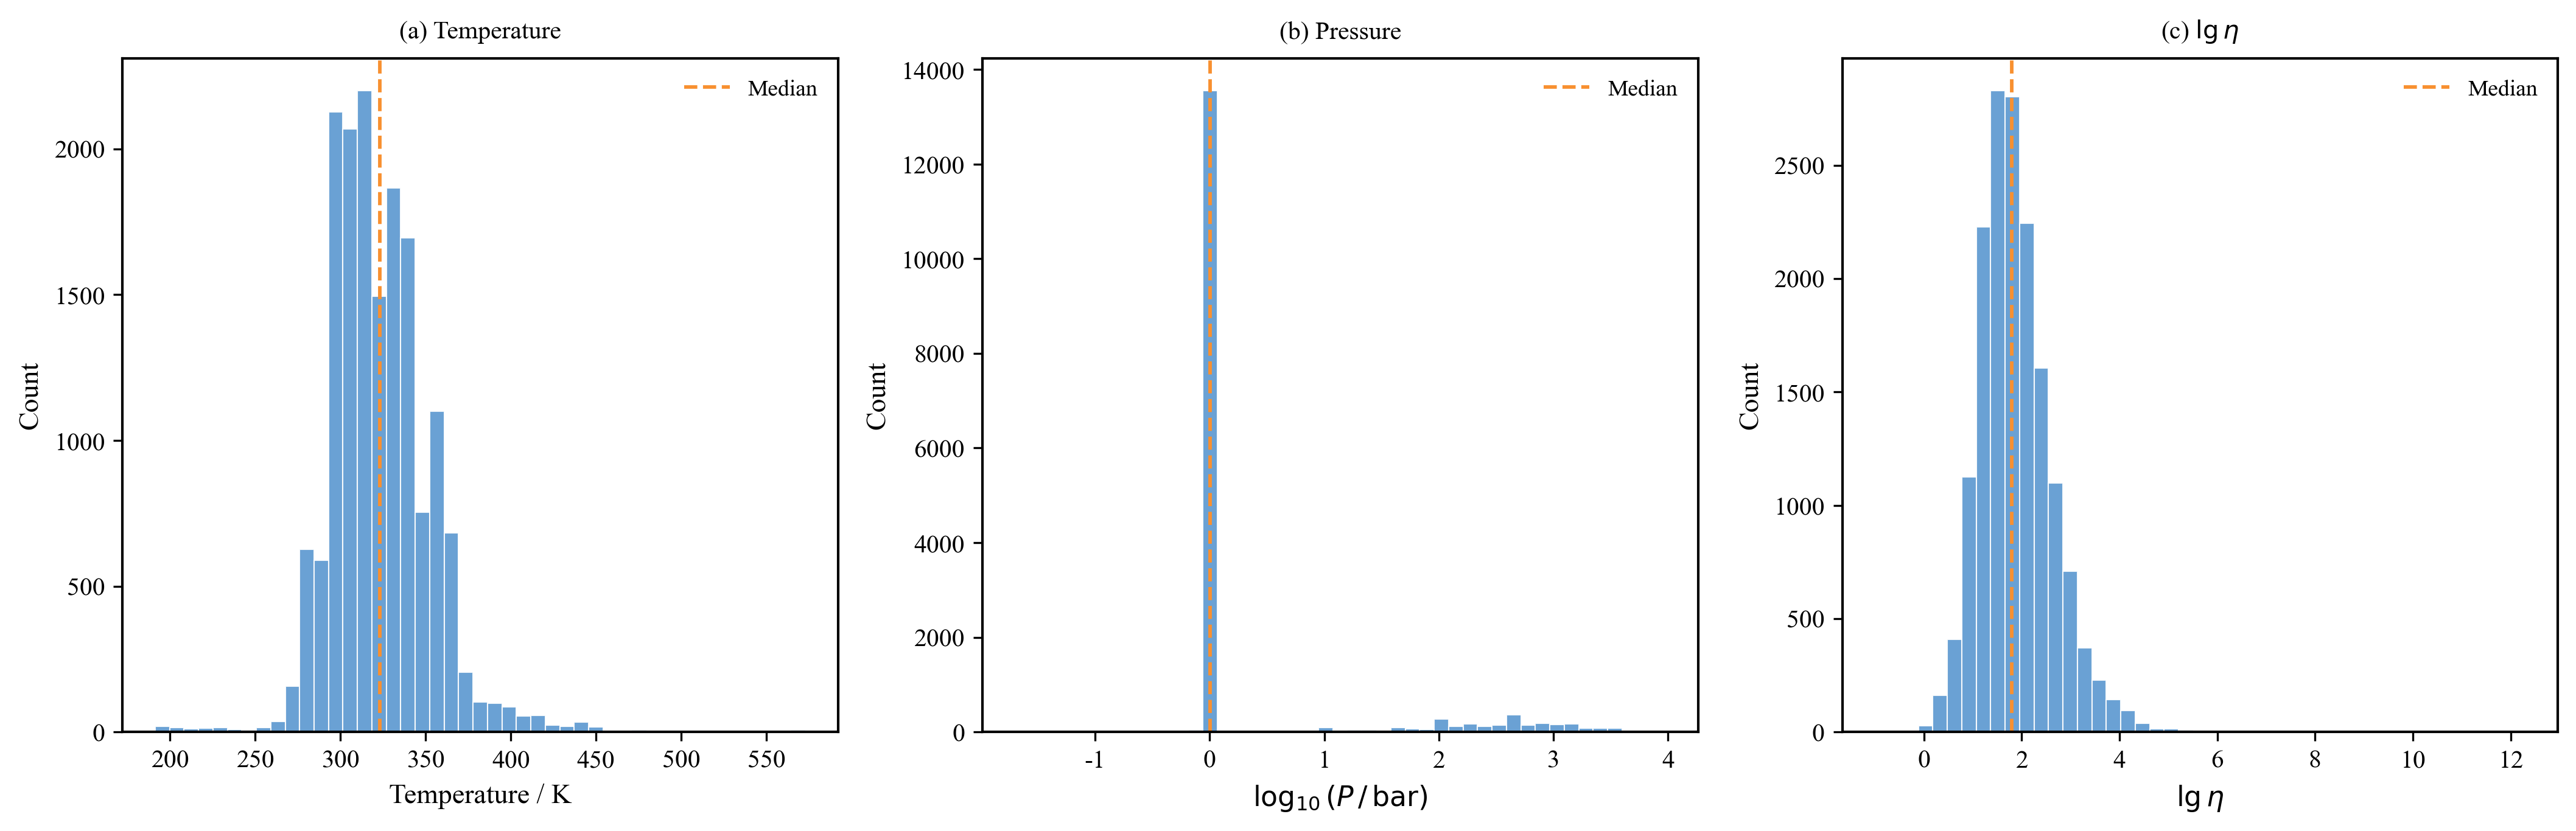

黏度数据集分布图已保存：

PNG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png\离子液体黏度数据集分布.png

SVG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg\离子液体黏度数据集分布.svg

PDF：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf\离子液体黏度数据集分布.pdf

绘图数据CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\离子液体黏度数据集分布.csv

统计汇总CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\离子液体黏度数据集分布_统计汇总.csv


In [6]:
# ============================================================
# Cell 5 | 离子液体黏度数据集分布图
# 绘图参数与大论文版本保持一致
#
# 分别保存至：
# figures/png
# figures/svg
# figures/pdf
# figures/csv
#
# 图片本体不嵌入中英文图题
# ============================================================


# ------------------------------------------------------------
# 1. 整理绘图数据
# ------------------------------------------------------------
plot_df_distribution = pd.DataFrame(
    {
        "T_K": pd.to_numeric(
            df_analysis[COL_T],
            errors="coerce",
        ),
        "P_bar": pd.to_numeric(
            df_analysis[COL_P],
            errors="coerce",
        ),
        "lg_eta": pd.to_numeric(
            df_analysis[COL_LG_ETA],
            errors="coerce",
        ),
    }
)


plot_df_distribution = (
    plot_df_distribution
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=[
            "T_K",
            "P_bar",
            "lg_eta",
        ]
    )
)


plot_df_distribution = (
    plot_df_distribution[
        plot_df_distribution["P_bar"] > 0
    ]
    .copy()
)


plot_df_distribution[
    "log10_P_bar"
] = np.log10(
    plot_df_distribution["P_bar"]
)


# ------------------------------------------------------------
# 2. 保存作图数据
# ------------------------------------------------------------
plot_data_path_distribution = (
    CSV_DIR
    / "离子液体黏度数据集分布.csv"
)

plot_df_distribution.to_csv(
    plot_data_path_distribution,
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 3. 保存统计汇总
# ------------------------------------------------------------
summary_distribution = pd.DataFrame(
    {
        "variable": [
            "T_K",
            "P_bar",
            "log10_P_bar",
            "lg_eta",
        ],
        "count": [
            plot_df_distribution[
                "T_K"
            ].count(),
            plot_df_distribution[
                "P_bar"
            ].count(),
            plot_df_distribution[
                "log10_P_bar"
            ].count(),
            plot_df_distribution[
                "lg_eta"
            ].count(),
        ],
        "min": [
            plot_df_distribution[
                "T_K"
            ].min(),
            plot_df_distribution[
                "P_bar"
            ].min(),
            plot_df_distribution[
                "log10_P_bar"
            ].min(),
            plot_df_distribution[
                "lg_eta"
            ].min(),
        ],
        "median": [
            plot_df_distribution[
                "T_K"
            ].median(),
            plot_df_distribution[
                "P_bar"
            ].median(),
            plot_df_distribution[
                "log10_P_bar"
            ].median(),
            plot_df_distribution[
                "lg_eta"
            ].median(),
        ],
        "mean": [
            plot_df_distribution[
                "T_K"
            ].mean(),
            plot_df_distribution[
                "P_bar"
            ].mean(),
            plot_df_distribution[
                "log10_P_bar"
            ].mean(),
            plot_df_distribution[
                "lg_eta"
            ].mean(),
        ],
        "max": [
            plot_df_distribution[
                "T_K"
            ].max(),
            plot_df_distribution[
                "P_bar"
            ].max(),
            plot_df_distribution[
                "log10_P_bar"
            ].max(),
            plot_df_distribution[
                "lg_eta"
            ].max(),
        ],
    }
)


summary_path_distribution = (
    CSV_DIR
    / "离子液体黏度数据集分布_统计汇总.csv"
)

summary_distribution.to_csv(
    summary_path_distribution,
    index=False,
    encoding="utf-8-sig",
)


print("绘图数据统计：")
display(summary_distribution)


# ------------------------------------------------------------
# 4. 绘图
# ------------------------------------------------------------
figure, axes = plt.subplots(
    1,
    3,
    figsize=(14.8, 4.9),
    dpi=300,
)


# ------------------------------------------------------------
# (a) 温度分布
# ------------------------------------------------------------
axes[0].hist(
    plot_df_distribution["T_K"],
    bins=45,
    color=BLUE,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90,
)

axes[0].axvline(
    plot_df_distribution[
        "T_K"
    ].median(),
    color=ORANGE,
    linestyle="--",
    linewidth=1.4,
    label="Median",
)

axes[0].set_xlabel(
    "Temperature / K",
    fontsize=11,
    fontproperties=FONT_EN,
)

axes[0].set_ylabel(
    "Count",
    fontsize=11,
    fontproperties=FONT_EN,
)

axes[0].set_title(
    "(a) Temperature",
    fontsize=12,
    fontproperties=FONT_EN,
    pad=8,
)

axes[0].legend(
    frameon=False,
    prop=font_manager.FontProperties(
        family=FONT_EN.get_name(),
        size=9,
    ),
)


# ------------------------------------------------------------
# (b) 压力分布
# ------------------------------------------------------------
axes[1].hist(
    plot_df_distribution["log10_P_bar"],
    bins=45,
    color=BLUE,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90,
)

axes[1].axvline(
    plot_df_distribution[
        "log10_P_bar"
    ].median(),
    color=ORANGE,
    linestyle="--",
    linewidth=1.4,
    label="Median",
)

axes[1].set_xlabel(
    r"$\log_{10}(P\,/\,\mathrm{bar})$",
    fontsize=11,
    fontproperties=FONT_EN,
)

axes[1].set_ylabel(
    "Count",
    fontsize=11,
    fontproperties=FONT_EN,
)

axes[1].set_title(
    "(b) Pressure",
    fontsize=12,
    fontproperties=FONT_EN,
    pad=8,
)

axes[1].legend(
    frameon=False,
    prop=font_manager.FontProperties(
        family=FONT_EN.get_name(),
        size=9,
    ),
)


# ------------------------------------------------------------
# (c) lgη分布
# ------------------------------------------------------------
axes[2].hist(
    plot_df_distribution["lg_eta"],
    bins=45,
    color=BLUE,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90,
)

axes[2].axvline(
    plot_df_distribution[
        "lg_eta"
    ].median(),
    color=ORANGE,
    linestyle="--",
    linewidth=1.4,
    label="Median",
)

axes[2].set_xlabel(
    r"$\mathrm{lg}\,\eta$",
    fontsize=11,
    fontproperties=FONT_EN,
)

axes[2].set_ylabel(
    "Count",
    fontsize=11,
    fontproperties=FONT_EN,
)

axes[2].set_title(
    r"(c) $\mathrm{lg}\,\eta$",
    fontsize=12,
    fontproperties=FONT_EN,
    pad=8,
)

axes[2].legend(
    frameon=False,
    prop=font_manager.FontProperties(
        family=FONT_EN.get_name(),
        size=9,
    ),
)


# ------------------------------------------------------------
# 5. 统一刻度和边框
# ------------------------------------------------------------
for axis in axes:
    axis.tick_params(
        axis="both",
        labelsize=10,
    )

    for tick_label in (
        axis.get_xticklabels()
        + axis.get_yticklabels()
    ):
        tick_label.set_fontproperties(
            FONT_EN
        )

    axis.grid(False)

    for spine in axis.spines.values():
        spine.set_linewidth(1.0)


figure.tight_layout(
    rect=[
        0.02,
        0.03,
        0.98,
        0.98,
    ]
)


# ------------------------------------------------------------
# 6. 分格式保存
# ------------------------------------------------------------
output_png_distribution = (
    PNG_DIR
    / "离子液体黏度数据集分布.png"
)

output_svg_distribution = (
    SVG_DIR
    / "离子液体黏度数据集分布.svg"
)

output_pdf_distribution = (
    PDF_DIR
    / "离子液体黏度数据集分布.pdf"
)


figure.savefig(
    output_png_distribution,
    dpi=600,
    bbox_inches="tight",
)

figure.savefig(
    output_svg_distribution,
    bbox_inches="tight",
)

figure.savefig(
    output_pdf_distribution,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


print("黏度数据集分布图已保存：")

print("\nPNG：")
print(output_png_distribution)

print("\nSVG：")
print(output_svg_distribution)

print("\nPDF：")
print(output_pdf_distribution)

print("\n绘图数据CSV：")
print(plot_data_path_distribution)

print("\n统计汇总CSV：")
print(summary_path_distribution)

T-P覆盖图数据统计：


,variable,count,min,median,mean,max
0,T_rep_K,16216,191.20,323.000000,323.308748,573.00000
1,P_rep_bar,16216,0.02,1.013250,111.486657,9500.00000
2,lg_eta,16216,-1.00,1.792392,1.901289,12.30103


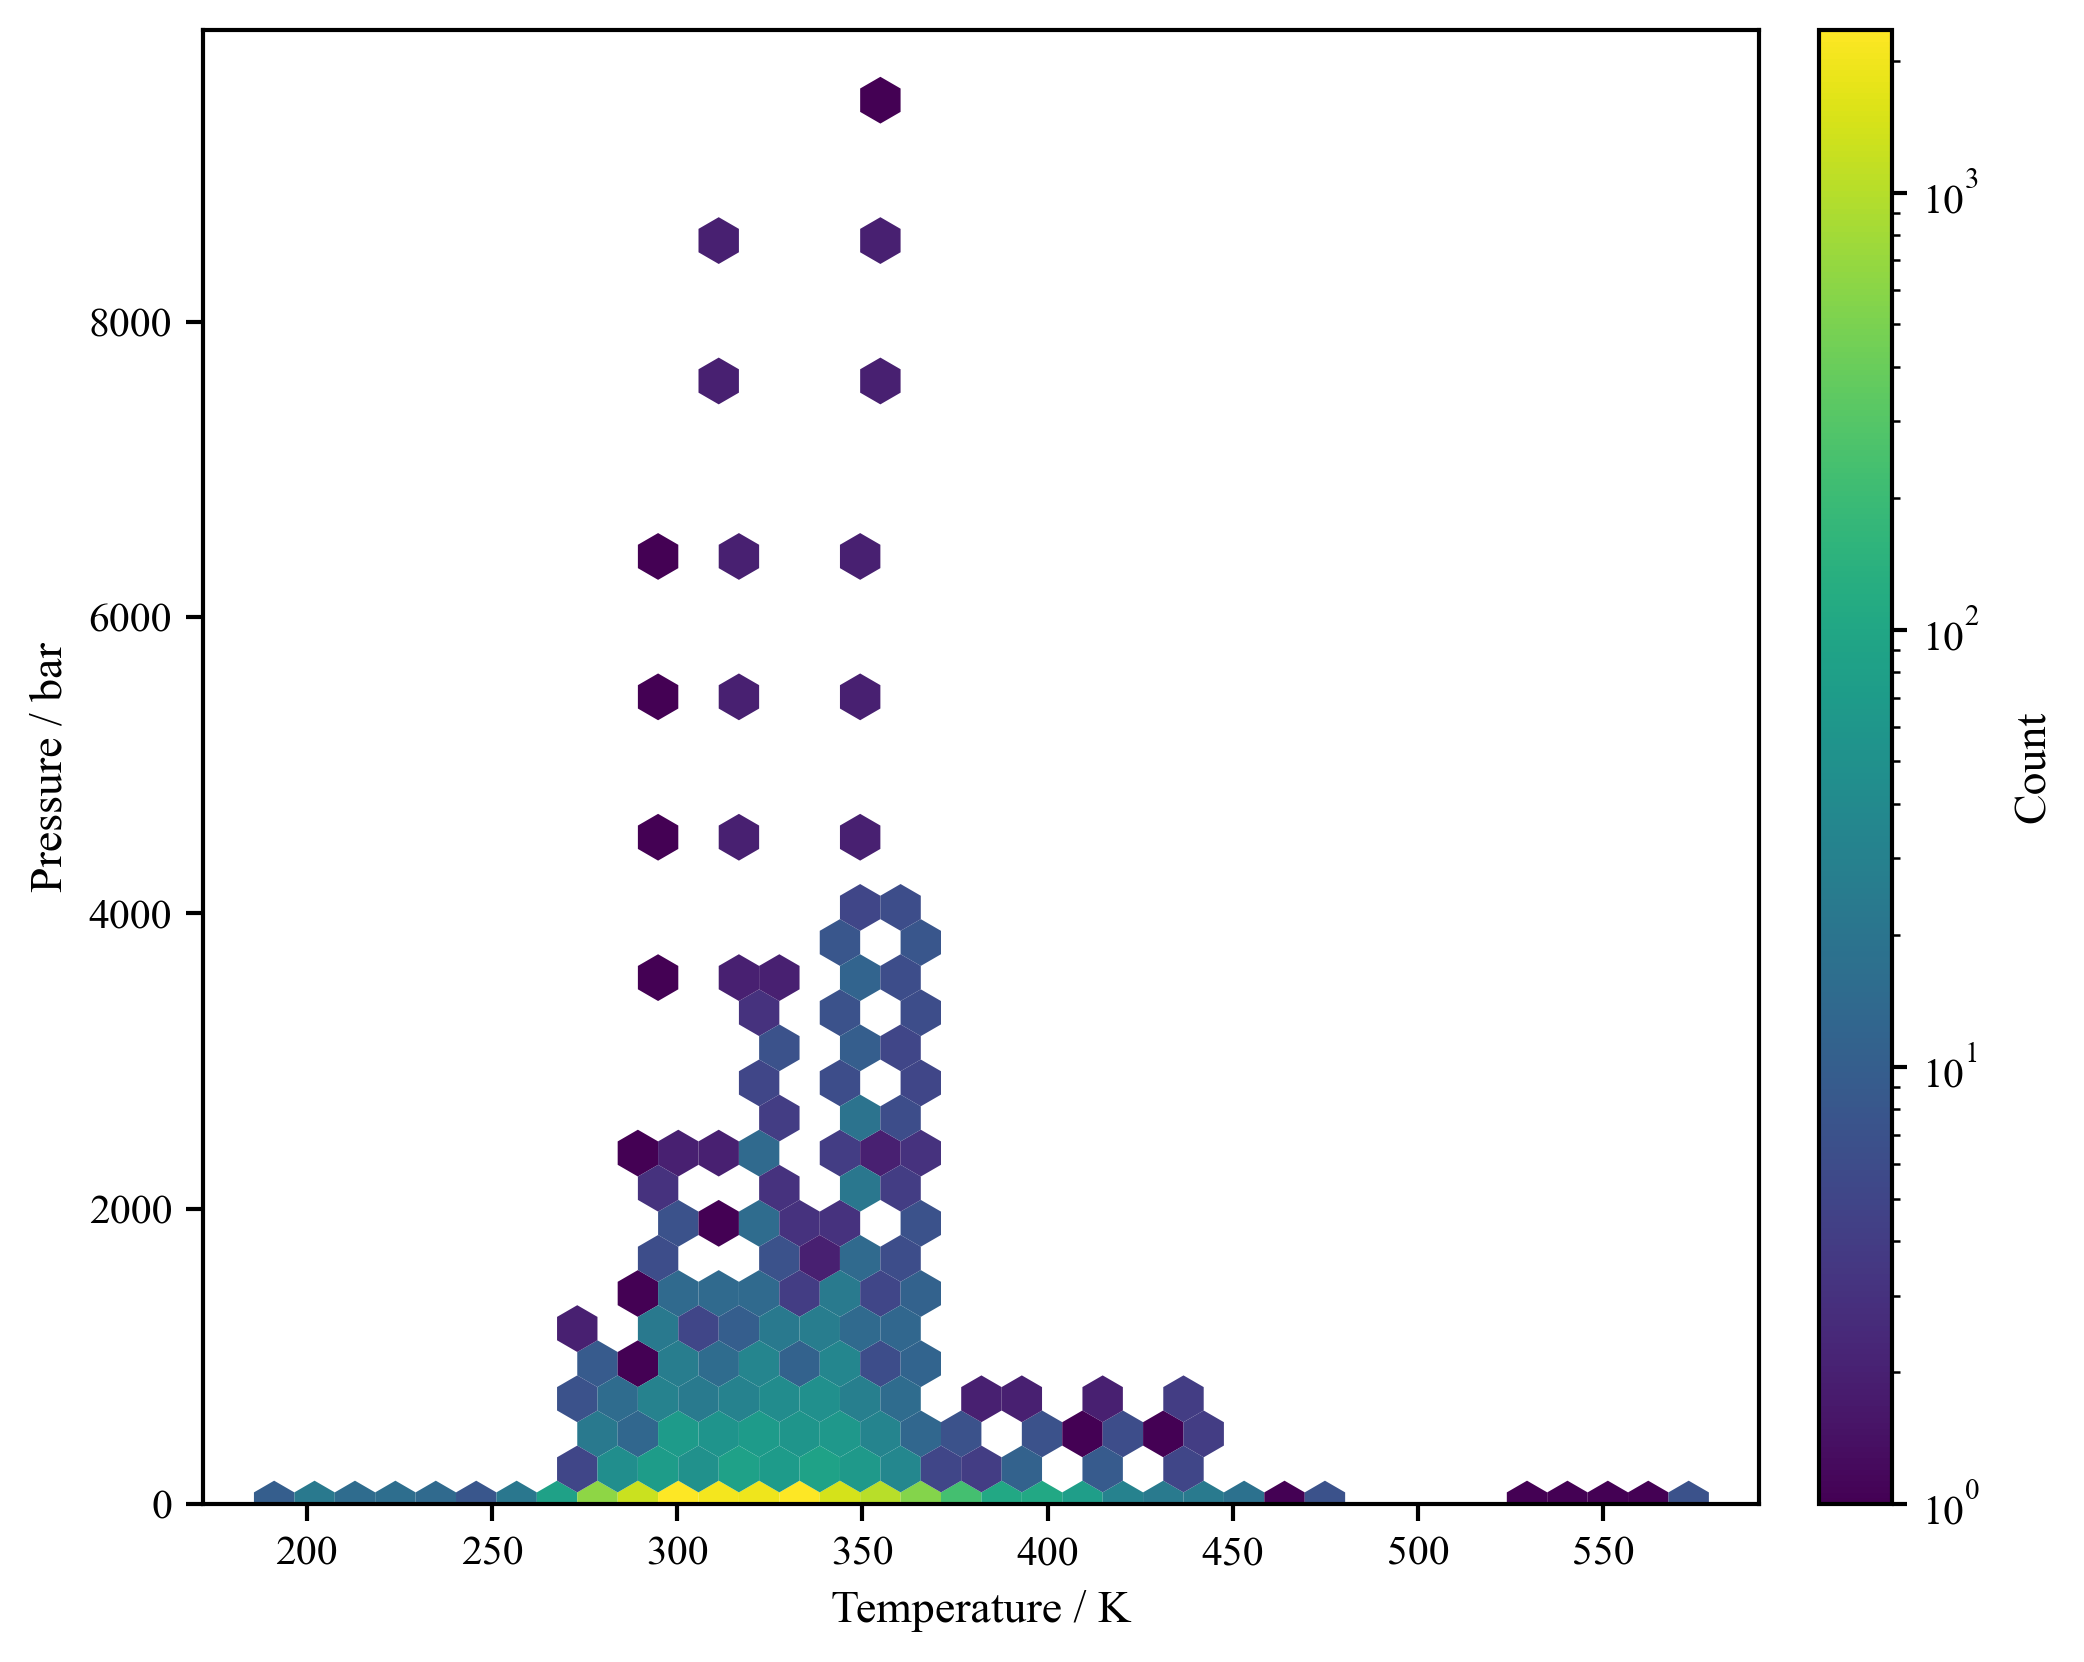

黏度数据T-P覆盖图已保存：

PNG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png\黏度数据T-P覆盖图.png

SVG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg\黏度数据T-P覆盖图.svg

PDF：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf\黏度数据T-P覆盖图.pdf

作图数据CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\黏度数据T-P覆盖图.csv


In [7]:
# ============================================================
# Cell 6 | 黏度数据T-P覆盖图
#
# 绘图规范：
# 1) 单幅图尺寸：7.4 × 6.0英寸
# 2) 横纵坐标名称：11 pt
# 3) 坐标刻度：10 pt
# 4) 颜色条名称：11 pt
# 5) 颜色条刻度：10 pt
# 6) 英文、数字和变量使用Times New Roman
# 7) 采用viridis配色和对数颜色归一化
# 8) 图片本体不嵌入图题
# 9) 分别保存PNG、SVG、PDF和作图数据CSV
# ============================================================

from matplotlib.colors import LogNorm


# ------------------------------------------------------------
# 1. 整理作图数据
# ------------------------------------------------------------
tp_coverage_data = pd.DataFrame(
    {
        "T_rep_K": pd.to_numeric(
            df_analysis[COL_T],
            errors="coerce",
        ),
        "P_rep_bar": pd.to_numeric(
            df_analysis[COL_P],
            errors="coerce",
        ),
        "lg_eta": pd.to_numeric(
            df_analysis[COL_LG_ETA],
            errors="coerce",
        ),
    }
)


tp_coverage_data = (
    tp_coverage_data
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=[
            "T_rep_K",
            "P_rep_bar",
            "lg_eta",
        ]
    )
)


# 压力必须大于0
tp_coverage_data = (
    tp_coverage_data[
        tp_coverage_data["P_rep_bar"] > 0
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. 保存作图数据CSV
# ------------------------------------------------------------
tp_csv_path = (
    CSV_DIR
    / "黏度数据T-P覆盖图.csv"
)


tp_coverage_data.to_csv(
    tp_csv_path,
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 3. 输出数据统计
# ------------------------------------------------------------
tp_summary = pd.DataFrame(
    {
        "variable": [
            "T_rep_K",
            "P_rep_bar",
            "lg_eta",
        ],
        "count": [
            tp_coverage_data["T_rep_K"].count(),
            tp_coverage_data["P_rep_bar"].count(),
            tp_coverage_data["lg_eta"].count(),
        ],
        "min": [
            tp_coverage_data["T_rep_K"].min(),
            tp_coverage_data["P_rep_bar"].min(),
            tp_coverage_data["lg_eta"].min(),
        ],
        "median": [
            tp_coverage_data["T_rep_K"].median(),
            tp_coverage_data["P_rep_bar"].median(),
            tp_coverage_data["lg_eta"].median(),
        ],
        "mean": [
            tp_coverage_data["T_rep_K"].mean(),
            tp_coverage_data["P_rep_bar"].mean(),
            tp_coverage_data["lg_eta"].mean(),
        ],
        "max": [
            tp_coverage_data["T_rep_K"].max(),
            tp_coverage_data["P_rep_bar"].max(),
            tp_coverage_data["lg_eta"].max(),
        ],
    }
)


print("T-P覆盖图数据统计：")
display(tp_summary)


# ------------------------------------------------------------
# 4. 绘图
#
# Cell 5为三联图，整幅尺寸14.8 × 4.9英寸；
# 本图为单幅图，采用约一半宽度的7.4 × 6.0英寸。
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=(7.4, 6.0),
    dpi=300,
)


hexbin_result = axis.hexbin(
    tp_coverage_data["T_rep_K"],
    tp_coverage_data["P_rep_bar"],
    gridsize=35,
    mincnt=1,
    cmap="viridis",
    norm=LogNorm(vmin=1),
    linewidths=0,
)


# ------------------------------------------------------------
# 5. 横纵坐标
# ------------------------------------------------------------
axis.set_xlabel(
    "Temperature / K",
    fontsize=11,
    fontproperties=FONT_EN,
)

axis.set_ylabel(
    "Pressure / bar",
    fontsize=11,
    fontproperties=FONT_EN,
)


axis.set_ylim(
    bottom=0,
)

axis.grid(False)


# ------------------------------------------------------------
# 6. 坐标刻度和边框
# ------------------------------------------------------------
axis.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1.0,
    labelsize=10,
)


for tick_label in (
    axis.get_xticklabels()
    + axis.get_yticklabels()
):
    tick_label.set_fontproperties(
        FONT_EN
    )


for spine in axis.spines.values():
    spine.set_linewidth(1.0)


# ------------------------------------------------------------
# 7. 颜色条
# ------------------------------------------------------------
colorbar = figure.colorbar(
    hexbin_result,
    ax=axis,
    fraction=0.046,
    pad=0.035,
)


colorbar.set_label(
    "Count",
    fontsize=11,
    fontproperties=FONT_EN,
    labelpad=8,
)


colorbar.ax.tick_params(
    direction="out",
    length=3.5,
    width=1.0,
    labelsize=10,
)


for tick_label in colorbar.ax.get_yticklabels():
    tick_label.set_fontproperties(
        FONT_EN
    )


colorbar.outline.set_linewidth(
    1.0
)


# ------------------------------------------------------------
# 8. 调整布局
# 图片本体不预留图题位置
# ------------------------------------------------------------
figure.tight_layout(
    rect=[
        0.03,
        0.04,
        0.98,
        0.98,
    ]
)


# ------------------------------------------------------------
# 9. 四种格式保存位置
# ------------------------------------------------------------
output_png_tp = (
    PNG_DIR
    / "黏度数据T-P覆盖图.png"
)

output_svg_tp = (
    SVG_DIR
    / "黏度数据T-P覆盖图.svg"
)

output_pdf_tp = (
    PDF_DIR
    / "黏度数据T-P覆盖图.pdf"
)


# ------------------------------------------------------------
# 10. 保存PNG、SVG和PDF
# ------------------------------------------------------------
figure.savefig(
    output_png_tp,
    dpi=600,
    bbox_inches="tight",
)

figure.savefig(
    output_svg_tp,
    bbox_inches="tight",
)

figure.savefig(
    output_pdf_tp,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 11. 输出完整保存路径
# ------------------------------------------------------------
print("黏度数据T-P覆盖图已保存：")

print("\nPNG：")
print(output_png_tp)

print("\nSVG：")
print(output_svg_tp)

print("\nPDF：")
print(output_pdf_tp)

print("\n作图数据CSV：")
print(tp_csv_path)

lg η与温度关系图数据统计：


,variable,count,min,median,max
0,T_rep_K,16216,191.20000,323.000000,573.000000
1,P_rep_bar,16216,0.02000,1.013250,9500.000000
2,log10_P_bar,16216,-1.69897,0.005717,3.977724
3,lg_eta,16216,-1.00000,1.792392,12.301030


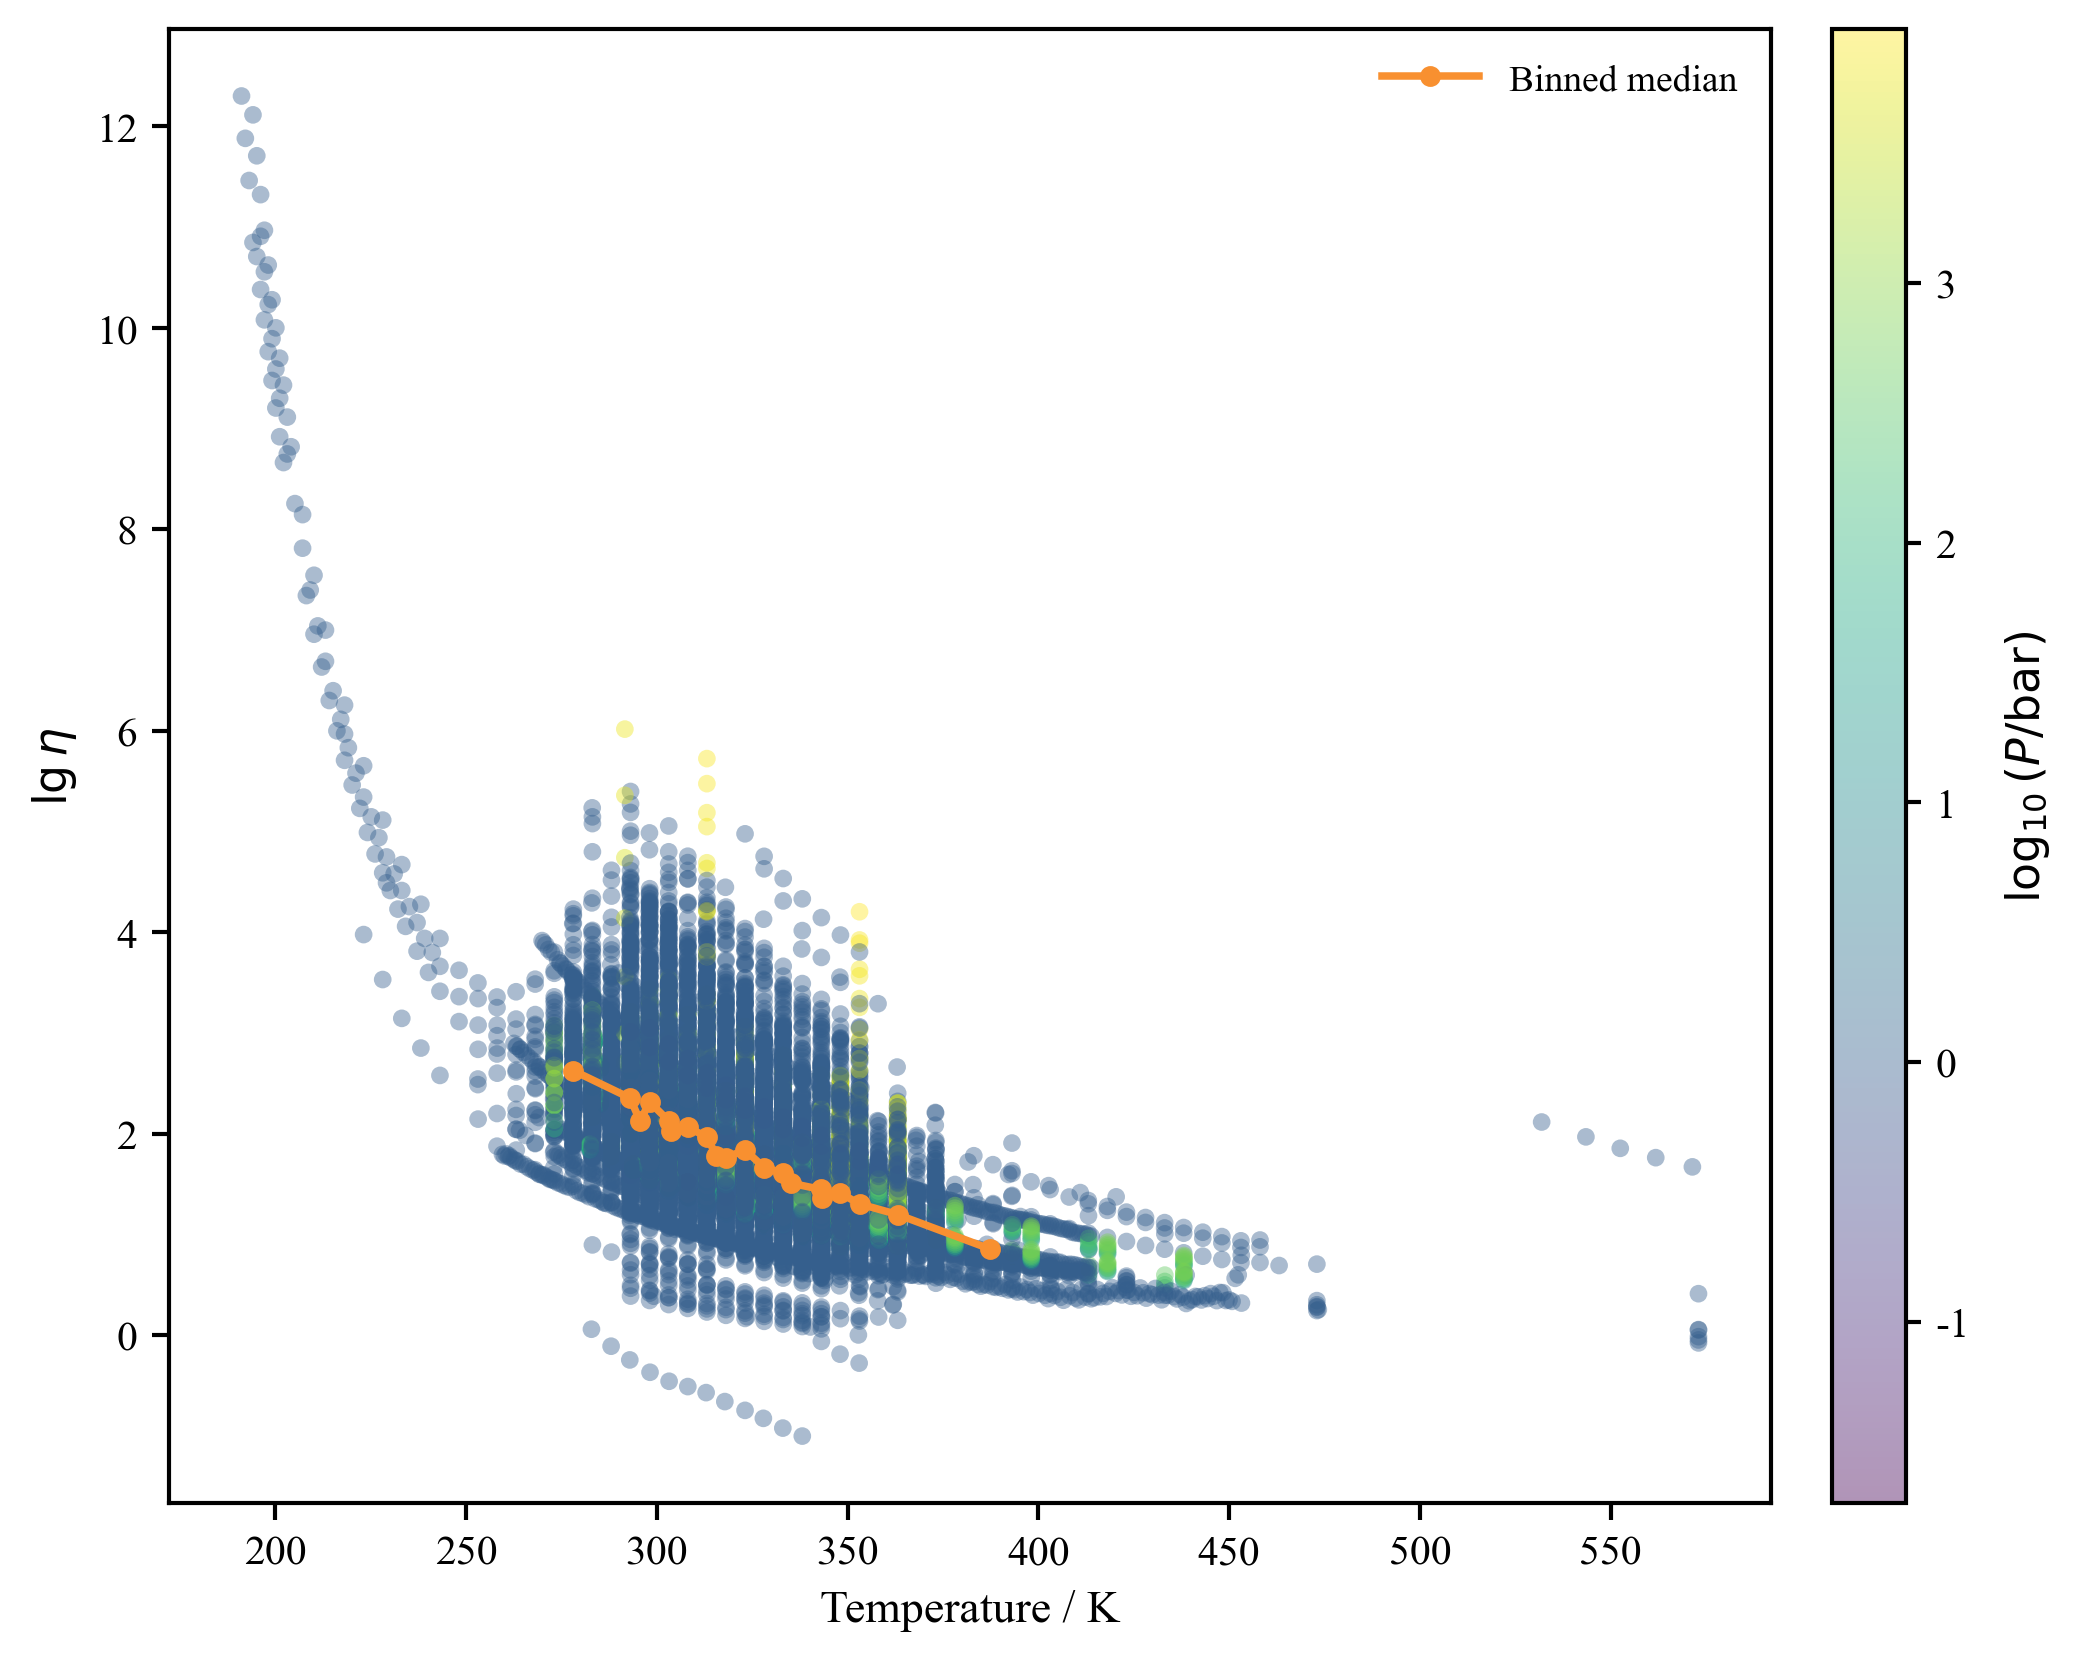

lg η与温度关系图已保存：

PNG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png\lgη与温度关系图.png

SVG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg\lgη与温度关系图.svg

PDF：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf\lgη与温度关系图.pdf

作图数据CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\lgη与温度关系图.csv

分箱趋势CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\lgη与温度关系图_分箱趋势.csv


In [8]:
# ============================================================
# Cell 7 | lg η与温度关系图
#
# 单幅图统一规范：
# 1) 画布尺寸：7.4 × 6.0英寸
# 2) 横纵坐标名称：11 pt
# 3) 坐标刻度：10 pt
# 4) 图例：9 pt
# 5) 颜色条名称：11 pt
# 6) 颜色条刻度：10 pt
# 7) 英文、数字和变量使用Times New Roman
# 8) 图片本体不嵌入图题
# 9) 分别保存PNG、SVG、PDF和对应作图数据CSV
# ============================================================


# ------------------------------------------------------------
# 1. 整理作图数据
# ------------------------------------------------------------
temperature_relation_data = pd.DataFrame(
    {
        "T_rep_K": pd.to_numeric(
            df_analysis[COL_T],
            errors="coerce",
        ),
        "P_rep_bar": pd.to_numeric(
            df_analysis[COL_P],
            errors="coerce",
        ),
        "lg_eta": pd.to_numeric(
            df_analysis[COL_LG_ETA],
            errors="coerce",
        ),
    }
)


temperature_relation_data = (
    temperature_relation_data
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=[
            "T_rep_K",
            "P_rep_bar",
            "lg_eta",
        ]
    )
)


temperature_relation_data = (
    temperature_relation_data[
        temperature_relation_data["P_rep_bar"] > 0
    ]
    .copy()
    .reset_index(drop=True)
)


# 压力用于连续颜色映射
temperature_relation_data[
    "log10_P_bar"
] = np.log10(
    temperature_relation_data["P_rep_bar"]
)


# ------------------------------------------------------------
# 2. 构建温度分箱中位数趋势
# ------------------------------------------------------------
temperature_trend = build_binned_median_trend(
    x_values=(
        temperature_relation_data["T_rep_K"]
    ),
    y_values=(
        temperature_relation_data["lg_eta"]
    ),
    n_bins=20,
)


# ------------------------------------------------------------
# 3. 保存作图数据
# ------------------------------------------------------------
temperature_relation_csv = (
    CSV_DIR
    / "lgη与温度关系图.csv"
)

temperature_trend_csv = (
    CSV_DIR
    / "lgη与温度关系图_分箱趋势.csv"
)


temperature_relation_data.to_csv(
    temperature_relation_csv,
    index=False,
    encoding="utf-8-sig",
)

temperature_trend.to_csv(
    temperature_trend_csv,
    index=False,
    encoding="utf-8-sig",
)


print("lg η与温度关系图数据统计：")

temperature_relation_summary = pd.DataFrame(
    {
        "variable": [
            "T_rep_K",
            "P_rep_bar",
            "log10_P_bar",
            "lg_eta",
        ],
        "count": [
            temperature_relation_data[
                "T_rep_K"
            ].count(),
            temperature_relation_data[
                "P_rep_bar"
            ].count(),
            temperature_relation_data[
                "log10_P_bar"
            ].count(),
            temperature_relation_data[
                "lg_eta"
            ].count(),
        ],
        "min": [
            temperature_relation_data[
                "T_rep_K"
            ].min(),
            temperature_relation_data[
                "P_rep_bar"
            ].min(),
            temperature_relation_data[
                "log10_P_bar"
            ].min(),
            temperature_relation_data[
                "lg_eta"
            ].min(),
        ],
        "median": [
            temperature_relation_data[
                "T_rep_K"
            ].median(),
            temperature_relation_data[
                "P_rep_bar"
            ].median(),
            temperature_relation_data[
                "log10_P_bar"
            ].median(),
            temperature_relation_data[
                "lg_eta"
            ].median(),
        ],
        "max": [
            temperature_relation_data[
                "T_rep_K"
            ].max(),
            temperature_relation_data[
                "P_rep_bar"
            ].max(),
            temperature_relation_data[
                "log10_P_bar"
            ].max(),
            temperature_relation_data[
                "lg_eta"
            ].max(),
        ],
    }
)

display(temperature_relation_summary)


# ------------------------------------------------------------
# 4. 绘图
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=(7.4, 6.0),
    dpi=300,
)


scatter_result = axis.scatter(
    temperature_relation_data["T_rep_K"],
    temperature_relation_data["lg_eta"],
    c=temperature_relation_data[
        "log10_P_bar"
    ],
    cmap="viridis",
    s=18,
    alpha=0.42,
    linewidths=0,
    rasterized=True,
)


# ------------------------------------------------------------
# 5. 绘制分箱中位数趋势
# ------------------------------------------------------------
if not temperature_trend.empty:
    axis.plot(
        temperature_trend["x_median"],
        temperature_trend["y_median"],
        color=ORANGE,
        linewidth=1.8,
        marker="o",
        markersize=4.0,
        markerfacecolor=ORANGE,
        markeredgecolor=ORANGE,
        label="Binned median",
        zorder=5,
    )


# ------------------------------------------------------------
# 6. 横纵坐标
# ------------------------------------------------------------
axis.set_xlabel(
    "Temperature / K",
    fontsize=11,
    fontproperties=FONT_EN,
)

axis.set_ylabel(
    r"$\mathrm{lg}\,\eta$",
    fontsize=11,
    fontproperties=FONT_EN,
)


axis.grid(False)


# ------------------------------------------------------------
# 7. 坐标刻度、边框和图例
# ------------------------------------------------------------
axis.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1.0,
    labelsize=10,
)


for tick_label in (
    axis.get_xticklabels()
    + axis.get_yticklabels()
):
    tick_label.set_fontproperties(
        FONT_EN
    )


for spine in axis.spines.values():
    spine.set_linewidth(1.0)


if not temperature_trend.empty:
    axis.legend(
        loc="upper right",
        frameon=False,
        prop=font_manager.FontProperties(
            family=FONT_EN.get_name(),
            size=9,
        ),
        handlelength=2.6,
    )


# ------------------------------------------------------------
# 8. 颜色条
# ------------------------------------------------------------
colorbar = figure.colorbar(
    scatter_result,
    ax=axis,
    fraction=0.046,
    pad=0.035,
)


colorbar.set_label(
    r"$\log_{10}(P/\mathrm{bar})$",
    fontsize=11,
    fontproperties=FONT_EN,
    labelpad=8,
)


colorbar.ax.tick_params(
    direction="out",
    length=3.5,
    width=1.0,
    labelsize=10,
)


for tick_label in colorbar.ax.get_yticklabels():
    tick_label.set_fontproperties(
        FONT_EN
    )


colorbar.outline.set_linewidth(
    1.0
)


# ------------------------------------------------------------
# 9. 调整布局
# ------------------------------------------------------------
figure.tight_layout(
    rect=[
        0.03,
        0.04,
        0.98,
        0.98,
    ]
)


# ------------------------------------------------------------
# 10. 四种格式保存位置
# ------------------------------------------------------------
output_png_temperature = (
    PNG_DIR
    / "lgη与温度关系图.png"
)

output_svg_temperature = (
    SVG_DIR
    / "lgη与温度关系图.svg"
)

output_pdf_temperature = (
    PDF_DIR
    / "lgη与温度关系图.pdf"
)


# ------------------------------------------------------------
# 11. 保存PNG、SVG和PDF
# ------------------------------------------------------------
figure.savefig(
    output_png_temperature,
    dpi=600,
    bbox_inches="tight",
)

figure.savefig(
    output_svg_temperature,
    bbox_inches="tight",
)

figure.savefig(
    output_pdf_temperature,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 12. 输出完整保存路径
# ------------------------------------------------------------
print("lg η与温度关系图已保存：")

print("\nPNG：")
print(output_png_temperature)

print("\nSVG：")
print(output_svg_temperature)

print("\nPDF：")
print(output_pdf_temperature)

print("\n作图数据CSV：")
print(temperature_relation_csv)

print("\n分箱趋势CSV：")
print(temperature_trend_csv)

黏度数据结构覆盖数量：


,structure_level,count
0,Ionic liquids,1295
1,Cations,583
2,Anions,202


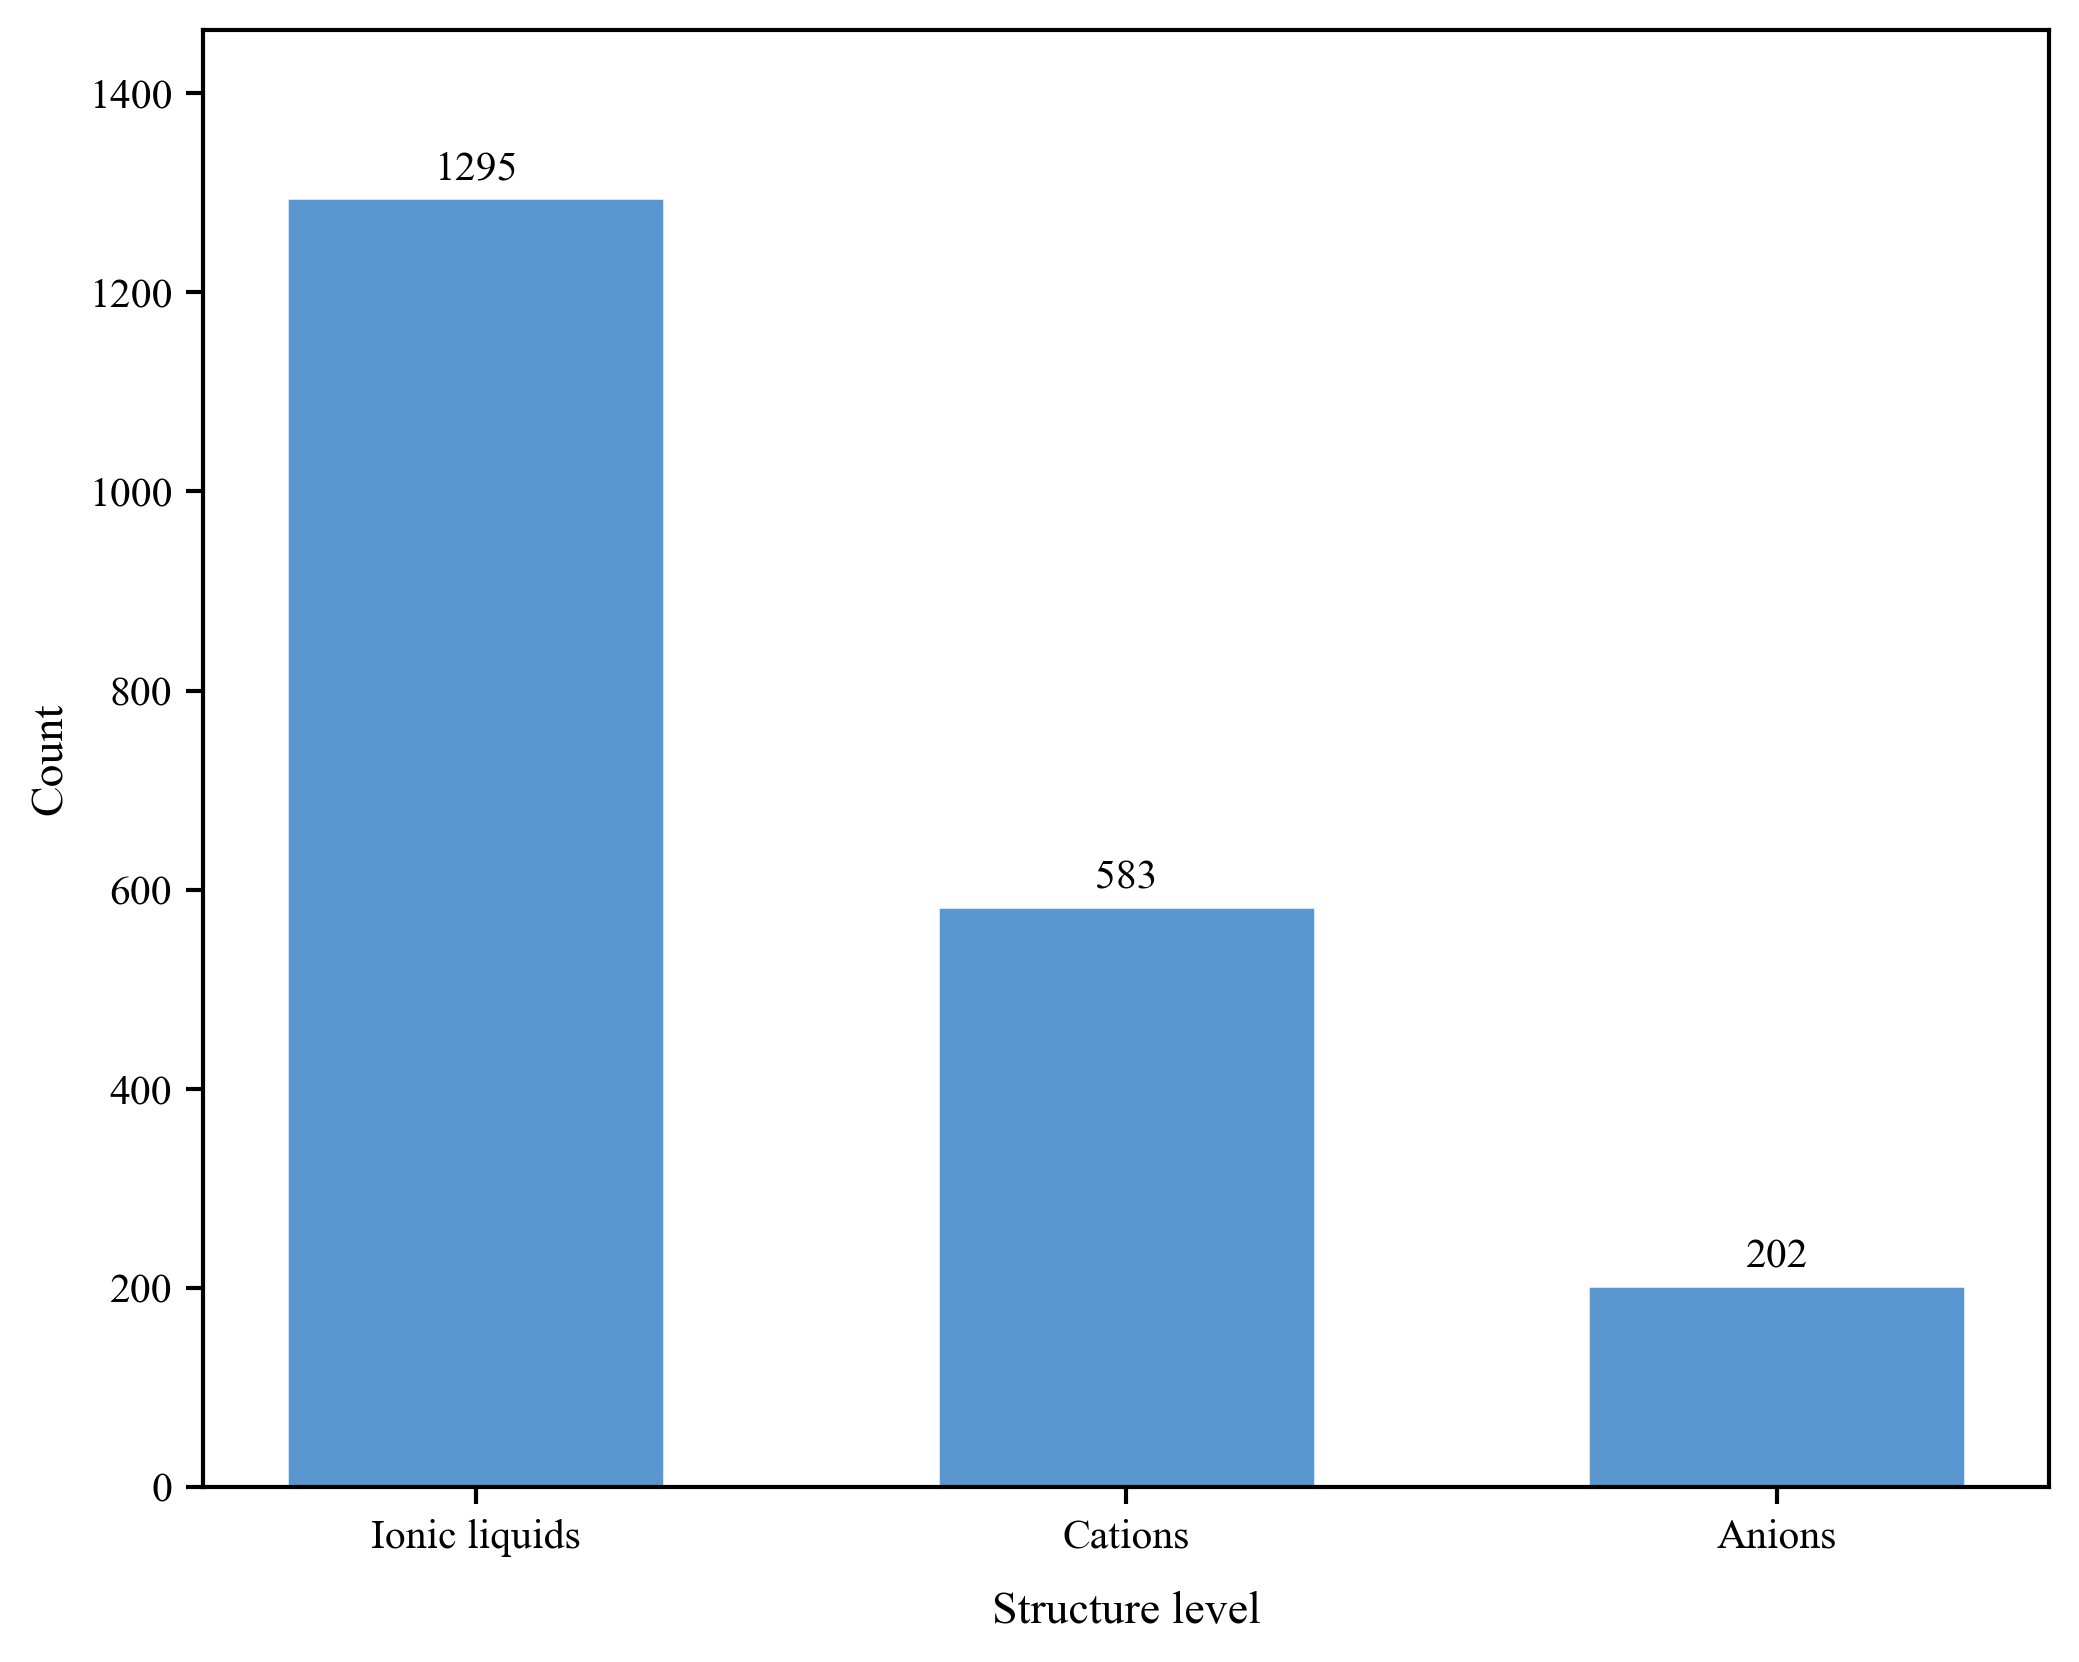

黏度数据结构覆盖数量图已保存：

PNG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png\黏度数据结构覆盖数量图.png

SVG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg\黏度数据结构覆盖数量图.svg

PDF：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf\黏度数据结构覆盖数量图.pdf

作图数据CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\黏度数据结构覆盖数量图.csv


In [9]:
# ============================================================
# Cell 8 | 黏度数据结构覆盖数量图
#
# 单幅图统一规范：
# 1) 画布尺寸：7.4 × 6.0英寸
# 2) 横纵坐标名称：11 pt
# 3) 坐标刻度：10 pt
# 4) 英文、数字和变量使用Times New Roman
# 5) 柱顶数字距柱体约0.8 mm
# 6) 图片本体不嵌入图题
# 7) 分别保存PNG、SVG、PDF和对应作图数据CSV
# ============================================================


# ------------------------------------------------------------
# 1. 统计结构覆盖数量
# ------------------------------------------------------------
structure_coverage = pd.DataFrame(
    {
        "structure_level": [
            "Ionic liquids",
            "Cations",
            "Anions",
        ],
        "count": [
            int(
                df_analysis[
                    COL_IL
                ].nunique()
            ),
            int(
                df_analysis[
                    COL_CAT
                ].nunique()
            ),
            int(
                df_analysis[
                    COL_ANI
                ].nunique()
            ),
        ],
    }
)


# ------------------------------------------------------------
# 2. 保存作图数据CSV
# ------------------------------------------------------------
structure_coverage_csv = (
    CSV_DIR
    / "黏度数据结构覆盖数量图.csv"
)


structure_coverage.to_csv(
    structure_coverage_csv,
    index=False,
    encoding="utf-8-sig",
)


print("黏度数据结构覆盖数量：")
display(structure_coverage)


# ------------------------------------------------------------
# 3. 绘图
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=(7.4, 6.0),
    dpi=300,
)


x_positions = np.arange(
    len(structure_coverage)
)


bars = axis.bar(
    x_positions,
    structure_coverage["count"],
    width=0.58,
    color=BLUE,
    edgecolor="white",
    linewidth=0.6,
)


# ------------------------------------------------------------
# 4. 横纵坐标
# ------------------------------------------------------------
axis.set_xlabel(
    "Structure level",
    fontsize=11,
    fontproperties=FONT_EN,
    labelpad=8,
)

axis.set_ylabel(
    "Count",
    fontsize=11,
    fontproperties=FONT_EN,
)


axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    structure_coverage[
        "structure_level"
    ].tolist()
)


axis.grid(False)


# ------------------------------------------------------------
# 5. 坐标刻度和边框
# ------------------------------------------------------------
axis.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1.0,
    labelsize=10,
)


for tick_label in (
    axis.get_xticklabels()
    + axis.get_yticklabels()
):
    tick_label.set_fontproperties(
        FONT_EN
    )


for spine in axis.spines.values():
    spine.set_linewidth(1.0)


# ------------------------------------------------------------
# 6. 设置纵坐标范围
# ------------------------------------------------------------
maximum_count = float(
    structure_coverage["count"].max()
)


axis.set_ylim(
    0,
    maximum_count * 1.13,
)


# ------------------------------------------------------------
# 7. 柱顶数值标注
#
# 0.8 mm约等于2.27 points，
# 因此xytext使用2.3 points。
# ------------------------------------------------------------
for bar, value in zip(
    bars,
    structure_coverage["count"],
):
    axis.annotate(
        f"{int(value)}",
        xy=(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 2.3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontproperties=FONT_EN,
    )


# ------------------------------------------------------------
# 8. 调整布局
# ------------------------------------------------------------
figure.tight_layout(
    rect=[
        0.03,
        0.04,
        0.98,
        0.98,
    ]
)


# ------------------------------------------------------------
# 9. 四种格式保存位置
# ------------------------------------------------------------
output_png_structure = (
    PNG_DIR
    / "黏度数据结构覆盖数量图.png"
)

output_svg_structure = (
    SVG_DIR
    / "黏度数据结构覆盖数量图.svg"
)

output_pdf_structure = (
    PDF_DIR
    / "黏度数据结构覆盖数量图.pdf"
)


# ------------------------------------------------------------
# 10. 保存PNG、SVG和PDF
# ------------------------------------------------------------
figure.savefig(
    output_png_structure,
    dpi=600,
    bbox_inches="tight",
)

figure.savefig(
    output_svg_structure,
    bbox_inches="tight",
)

figure.savefig(
    output_pdf_structure,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 11. 输出完整保存路径
# ------------------------------------------------------------
print("黏度数据结构覆盖数量图已保存：")

print("\nPNG：")
print(output_png_structure)

print("\nSVG：")
print(output_svg_structure)

print("\nPDF：")
print(output_pdf_structure)

print("\n作图数据CSV：")
print(structure_coverage_csv)

样本数量最多的20种离子液体：


,rank,IL_key,n_samples
0,1,CCn1cc[n+](C)c1||O=S(=O)([N-]S(=O)(=O)C(F)(F)F...,284
1,2,CCn1cc[n+](C)c1||N#CN=C=[N-],277
2,3,CCCCCCCCn1cc[n+](C)c1||F[P-](F)(F)(F)(F)F,263
3,4,CCCCn1cc[n+](C)c1||[Cl][Fe-]([Cl])([Cl])[Cl],251
4,5,CCCCCCn1cc[n+](C)c1||F[B-](F)(F)F,216
5,6,CCCCn1cc[n+](C)c1||FC(F)(F)C(F)(F)[P-](F)(F)(F...,205
6,7,CCCCCCn1cc[n+](C)c1||O=S(=O)([N-]S(=O)(=O)C(F)...,199
7,8,CCCCn1cc[n+](C)c1||F[B-](F)(F)F,191
8,9,CCCCn1cc[n+](C)c1||F[P-](F)(F)(F)(F)F,180
9,10,CCCCn1cc[n+](C)c1||O=S(=O)([N-]S(=O)(=O)C(F)(F...,177


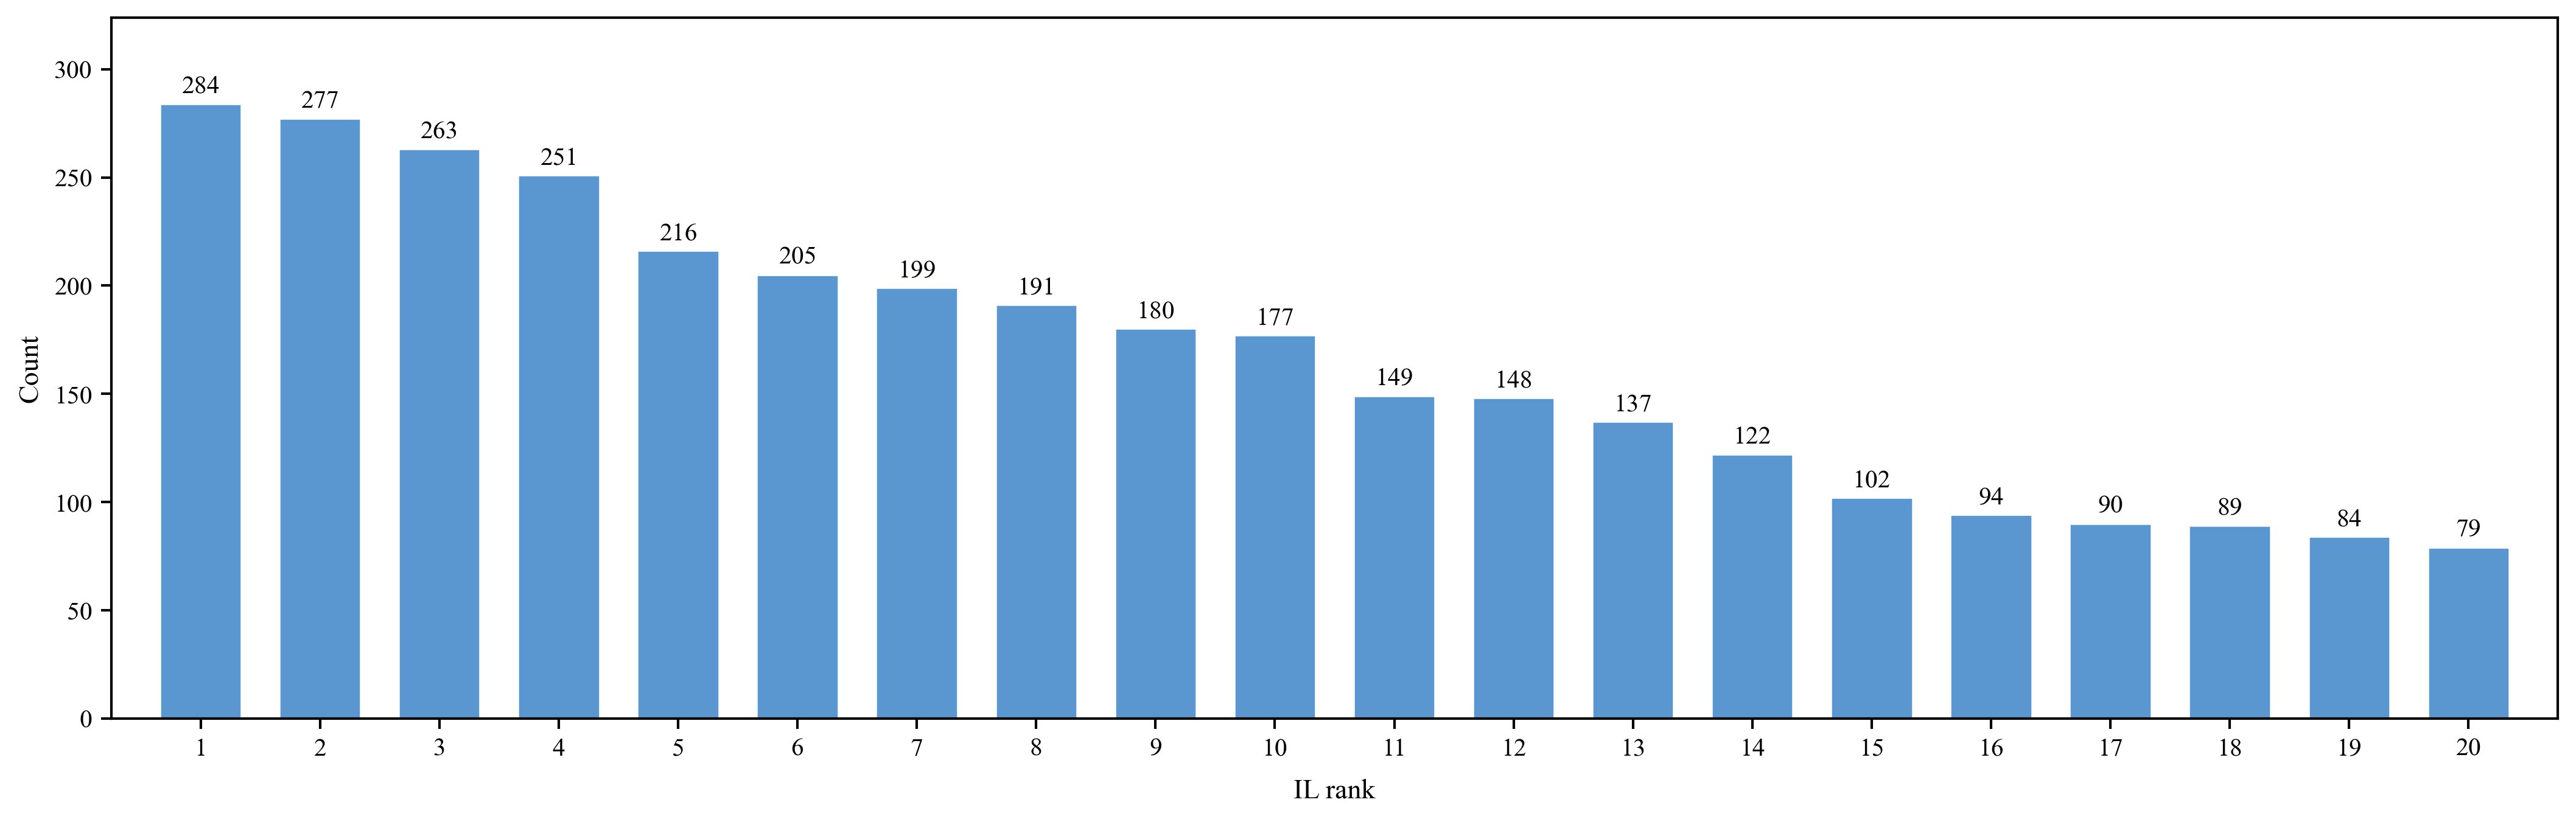

样本数Top20离子液体图已保存：

PNG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png\样本数Top20离子液体图.png

SVG：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg\样本数Top20离子液体图.svg

PDF：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf\样本数Top20离子液体图.pdf

作图数据CSV：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv\样本数Top20离子液体图.csv


In [10]:
# ============================================================
# Cell 9 | 样本数Top20离子液体图
#
# 绘图规范：
# 1) 画布尺寸与Cell 5一致：14.8 × 4.9英寸
# 2) 横纵坐标名称：11 pt
# 3) 坐标刻度：10 pt
# 4) 柱顶数字：10 pt，距柱体约0.8 mm
# 5) 英文、数字和变量使用Times New Roman
# 6) 横坐标使用等间距位置，标签显示1～20
# 7) 图片本体不嵌入图题
# 8) 分别保存PNG、SVG、PDF和对应作图数据CSV
# ============================================================


# ------------------------------------------------------------
# 1. 统计样本数量最多的20种离子液体
# ------------------------------------------------------------
top20_il_counts = (
    df_analysis
    .groupby(
        COL_IL,
        dropna=False,
    )
    .size()
    .sort_values(
        ascending=False
    )
    .head(20)
    .reset_index(
        name="n_samples"
    )
)


top20_il_counts.insert(
    0,
    "rank",
    np.arange(
        1,
        len(top20_il_counts) + 1,
        dtype=int,
    ),
)


# ------------------------------------------------------------
# 2. 保存作图数据CSV
# ------------------------------------------------------------
top20_il_csv = (
    CSV_DIR
    / "样本数Top20离子液体图.csv"
)


top20_il_counts.to_csv(
    top20_il_csv,
    index=False,
    encoding="utf-8-sig",
)


print("样本数量最多的20种离子液体：")
display(top20_il_counts)


# ------------------------------------------------------------
# 3. 建立严格等间距的横坐标位置
#
# 柱子位置固定为0～19；
# 显示标签为1～20。
# 不再直接把rank数值作为绘图位置。
# ------------------------------------------------------------
n_bars = len(top20_il_counts)

x_positions = np.arange(
    n_bars,
    dtype=float,
)

x_tick_labels = (
    top20_il_counts["rank"]
    .astype(int)
    .astype(str)
    .tolist()
)


# ------------------------------------------------------------
# 4. 绘图
# 画布尺寸与Cell 5保持一致
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=(14.8, 4.9),
    dpi=300,
)


bars = axis.bar(
    x_positions,
    top20_il_counts["n_samples"],
    width=0.68,
    color=BLUE,
    edgecolor="white",
    linewidth=0.6,
    align="center",
)


# ------------------------------------------------------------
# 5. 横纵坐标
# ------------------------------------------------------------
axis.set_xlabel(
    "IL rank",
    fontsize=11,
    fontproperties=FONT_EN,
    labelpad=7,
)

axis.set_ylabel(
    "Count",
    fontsize=11,
    fontproperties=FONT_EN,
)


# 柱子位置和刻度位置使用同一组等间距坐标
axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    x_tick_labels
)


# 左右留白保持一致
axis.set_xlim(
    -0.75,
    n_bars - 0.25,
)


axis.grid(False)


# ------------------------------------------------------------
# 6. 坐标刻度和边框
# ------------------------------------------------------------
axis.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1.0,
    labelsize=10,
)


for tick_label in (
    axis.get_xticklabels()
    + axis.get_yticklabels()
):
    tick_label.set_fontproperties(
        FONT_EN
    )


for spine in axis.spines.values():
    spine.set_linewidth(1.0)


# ------------------------------------------------------------
# 7. 设置纵坐标上限
# 为柱顶数字保留空间
# ------------------------------------------------------------
maximum_count = float(
    top20_il_counts["n_samples"].max()
)


axis.set_ylim(
    0,
    maximum_count * 1.14,
)


# ------------------------------------------------------------
# 8. 柱顶数值标注
#
# 0.8 mm约等于2.27 points，
# 因此xytext设置为2.3 points。
# ------------------------------------------------------------
for bar, value in zip(
    bars,
    top20_il_counts["n_samples"],
):
    axis.annotate(
        f"{int(value)}",
        xy=(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 2.3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontproperties=FONT_EN,
        clip_on=False,
    )


# ------------------------------------------------------------
# 9. 调整布局
# 图片本体不预留图题位置
# ------------------------------------------------------------
figure.tight_layout(
    rect=[
        0.02,
        0.04,
        0.98,
        0.98,
    ]
)


# ------------------------------------------------------------
# 10. 四种格式保存位置
# ------------------------------------------------------------
output_png_top20 = (
    PNG_DIR
    / "样本数Top20离子液体图.png"
)

output_svg_top20 = (
    SVG_DIR
    / "样本数Top20离子液体图.svg"
)

output_pdf_top20 = (
    PDF_DIR
    / "样本数Top20离子液体图.pdf"
)


# ------------------------------------------------------------
# 11. 保存PNG、SVG和PDF
# ------------------------------------------------------------
figure.savefig(
    output_png_top20,
    dpi=600,
    bbox_inches="tight",
)

figure.savefig(
    output_svg_top20,
    bbox_inches="tight",
)

figure.savefig(
    output_pdf_top20,
    bbox_inches="tight",
)


plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 12. 输出完整保存路径
# ------------------------------------------------------------
print("样本数Top20离子液体图已保存：")

print("\nPNG：")
print(output_png_top20)

print("\nSVG：")
print(output_svg_top20)

print("\nPDF：")
print(output_pdf_top20)

print("\n作图数据CSV：")
print(top20_il_csv)

In [11]:
# ============================================================
# Cell 10 | 保存EDA运行记录
# ============================================================

MANIFEST_JSON = (
    MANIFEST_DIR
    / "粘度建模数据分析EDA_manifest.json"
)


manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "notebook_name": NOTEBOOK_NAME,
    "project_root": str(
        PROJECT_ROOT
    ),
    "experiment_root": str(
        EXPERIMENT_ROOT
    ),
    "input_file": str(
        ML_READY_CSV
    ),
    "output_root": str(
        EDA_ROOT
    ),
    "figures_root": str(
        FIGURES_ROOT
    ),
    "png_directory": str(
        PNG_DIR
    ),
    "svg_directory": str(
        SVG_DIR
    ),
    "pdf_directory": str(
        PDF_DIR
    ),
    "csv_directory": str(
        CSV_DIR
    ),
    "manifest_directory": str(
        MANIFEST_DIR
    ),
    "target_property": "viscosity",
    "target_for_modeling": "lg_eta",
    "n_rows": int(
        len(df_analysis)
    ),
    "n_unique_ionic_liquids": int(
        df_analysis[
            COL_IL
        ].nunique()
    ),
    "n_unique_cations": int(
        df_analysis[
            COL_CAT
        ].nunique()
    ),
    "n_unique_anions": int(
        df_analysis[
            COL_ANI
        ].nunique()
    ),
    "n_with_valid_uncertainty": int(
        df_analysis[
            COL_LG_ETA_SIGMA
        ].notna().sum()
    ),
    "n_suspicious_eta_records": int(
        len(suspicious_records)
    ),
    "eta_min_mPa_s": float(
        df_analysis[
            COL_ETA
        ].min()
    ),
    "eta_max_mPa_s": float(
        df_analysis[
            COL_ETA
        ].max()
    ),
    "lg_eta_min": float(
        df_analysis[
            COL_LG_ETA
        ].min()
    ),
    "lg_eta_max": float(
        df_analysis[
            COL_LG_ETA
        ].max()
    ),
    "png_files": [
        "离子液体黏度数据集分布.png",
        "黏度数据T-P覆盖图.png",
        "lgη与温度关系图.png",
        "黏度数据结构覆盖数量图.png",
        "样本数Top20离子液体图.png",
    ],
    "svg_files": [
        "离子液体黏度数据集分布.svg",
        "黏度数据T-P覆盖图.svg",
        "lgη与温度关系图.svg",
        "黏度数据结构覆盖数量图.svg",
        "样本数Top20离子液体图.svg",
    ],
    "pdf_files": [
        "离子液体黏度数据集分布.pdf",
        "黏度数据T-P覆盖图.pdf",
        "lgη与温度关系图.pdf",
        "黏度数据结构覆盖数量图.pdf",
        "样本数Top20离子液体图.pdf",
    ],
    "csv_files": [
        "黏度建模数据概况.csv",
        "黏度建模数据描述性统计.csv",
        "黏度极端值检查.csv",
        "离子液体黏度数据集分布.csv",
        "离子液体黏度数据集分布_统计汇总.csv",
        "黏度数据T-P覆盖图.csv",
        "lgη与温度关系图.csv",
        "lgη与温度关系图_分箱趋势.csv",
        "黏度数据结构覆盖数量图.csv",
        "样本数Top20离子液体图.csv",
    ],
    "notes": (
        "本Notebook仅分析黏度数据。"
        "所有图片分别保存至png、svg和pdf文件夹，"
        "所有作图数据及统计结果保存至csv文件夹。"
        "图片本体不嵌入中英文图题。"
        "按照原预处理规则标记可疑黏度记录，"
        "但不在EDA阶段删除或修改任何建模样本。"
    ),
}


with open(
    MANIFEST_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        ensure_ascii=False,
        indent=2,
    )


print("EDA运行记录已保存：")
print(MANIFEST_JSON)

print("\nPNG目录：")
print(PNG_DIR)

print("\nSVG目录：")
print(SVG_DIR)

print("\nPDF目录：")
print(PDF_DIR)

print("\nCSV目录：")
print(CSV_DIR)

EDA运行记录已保存：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\manifest\粘度建模数据分析EDA_manifest.json

PNG目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png

SVG目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg

PDF目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf

CSV目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv


In [12]:
# ============================================================
# Cell 11 | 最终输出文件检查
# 分别检查png、svg、pdf和csv文件夹
# ============================================================

expected_figure_stems = [
    "离子液体黏度数据集分布",
    "黏度数据T-P覆盖图",
    "lgη与温度关系图",
    "黏度数据结构覆盖数量图",
    "样本数Top20离子液体图",
]


expected_csv_files = [
    "黏度建模数据概况.csv",
    "黏度建模数据描述性统计.csv",
    "黏度极端值检查.csv",
    "离子液体黏度数据集分布.csv",
    "离子液体黏度数据集分布_统计汇总.csv",
    "黏度数据T-P覆盖图.csv",
    "lgη与温度关系图.csv",
    "lgη与温度关系图_分箱趋势.csv",
    "黏度数据结构覆盖数量图.csv",
    "样本数Top20离子液体图.csv",
]


file_check_rows = []


# ------------------------------------------------------------
# 1. 检查PNG
# ------------------------------------------------------------
for stem in expected_figure_stems:
    file_path = (
        PNG_DIR
        / f"{stem}.png"
    )

    file_check_rows.append(
        {
            "file_type": "png",
            "file_name": file_path.name,
            "full_path": str(file_path),
            "exists": file_path.exists(),
        }
    )


# ------------------------------------------------------------
# 2. 检查SVG
# ------------------------------------------------------------
for stem in expected_figure_stems:
    file_path = (
        SVG_DIR
        / f"{stem}.svg"
    )

    file_check_rows.append(
        {
            "file_type": "svg",
            "file_name": file_path.name,
            "full_path": str(file_path),
            "exists": file_path.exists(),
        }
    )


# ------------------------------------------------------------
# 3. 检查PDF
# ------------------------------------------------------------
for stem in expected_figure_stems:
    file_path = (
        PDF_DIR
        / f"{stem}.pdf"
    )

    file_check_rows.append(
        {
            "file_type": "pdf",
            "file_name": file_path.name,
            "full_path": str(file_path),
            "exists": file_path.exists(),
        }
    )


# ------------------------------------------------------------
# 4. 检查CSV
# ------------------------------------------------------------
for filename in expected_csv_files:
    file_path = (
        CSV_DIR
        / filename
    )

    file_check_rows.append(
        {
            "file_type": "csv",
            "file_name": file_path.name,
            "full_path": str(file_path),
            "exists": file_path.exists(),
        }
    )


# ------------------------------------------------------------
# 5. 检查Manifest
# ------------------------------------------------------------
file_check_rows.append(
    {
        "file_type": "manifest",
        "file_name": MANIFEST_JSON.name,
        "full_path": str(MANIFEST_JSON),
        "exists": MANIFEST_JSON.exists(),
    }
)


output_file_check = pd.DataFrame(
    file_check_rows
)


OUTPUT_CHECK_CSV = (
    MANIFEST_DIR
    / "EDA输出文件检查.csv"
)


output_file_check.to_csv(
    OUTPUT_CHECK_CSV,
    index=False,
    encoding="utf-8-sig",
)


print("最终输出文件检查：")
display(output_file_check)


n_existing_files = int(
    output_file_check[
        "exists"
    ].sum()
)

n_expected_files = len(
    output_file_check
)


print("\n存在文件数：")
print(
    n_existing_files,
    "/",
    n_expected_files,
)


print("\n各格式文件数量：")
display(
    output_file_check
    .groupby("file_type")
    .agg(
        预期数量=(
            "file_name",
            "size",
        ),
        已存在数量=(
            "exists",
            "sum",
        ),
    )
    .reset_index()
)


if not output_file_check["exists"].all():
    missing_output_files = (
        output_file_check.loc[
            ~output_file_check["exists"],
            [
                "file_type",
                "file_name",
                "full_path",
            ],
        ]
    )

    print("\n缺失的输出文件：")
    display(missing_output_files)

    raise RuntimeError(
        "存在未成功生成的EDA输出文件。"
    )


print(
    "\n粘度建模数据分析EDA_10点留出版.ipynb"
    "运行完成。"
)

print("\nPNG目录：")
print(PNG_DIR)

print("\nSVG目录：")
print(SVG_DIR)

print("\nPDF目录：")
print(PDF_DIR)

print("\nCSV目录：")
print(CSV_DIR)

print("\nManifest目录：")
print(MANIFEST_DIR)

最终输出文件检查：


,file_type,file_name,full_path,exists
0,png,离子液体黏度数据集分布.png,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
1,png,黏度数据T-P覆盖图.png,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
2,png,lgη与温度关系图.png,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
3,png,黏度数据结构覆盖数量图.png,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
4,png,样本数Top20离子液体图.png,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
5,svg,离子液体黏度数据集分布.svg,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
6,svg,黏度数据T-P覆盖图.svg,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
7,svg,lgη与温度关系图.svg,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
8,svg,黏度数据结构覆盖数量图.svg,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True
9,svg,样本数Top20离子液体图.svg,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True



存在文件数：
26 / 26

各格式文件数量：


,file_type,预期数量,已存在数量
0,csv,10,10
1,manifest,1,1
2,pdf,5,5
3,png,5,5
4,svg,5,5



粘度建模数据分析EDA_10点留出版.ipynb运行完成。

PNG目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\png

SVG目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\svg

PDF目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\pdf

CSV目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\figures\csv

Manifest目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\EDA\manifest
